# Autism Risk Screening — Southern Africa (Lesotho)
### Multimodal AI Pipeline

**Pipeline sections:**
1. Imports & setup
2. Data loading & preprocessing
3. Exploratory data analysis
4. Model training (behavioural + demographic XGBoost)
5. Late fusion & evaluation
6. DHS threshold recalibration
7. **Comorbidity adjustment — population-level sensitivity sweep**
8. **Comorbidity adjustment — individual-level layer (simulated DHS-linked status)**
9. SHAP explainability
10. Cultural alignment / item-level perturbation analysis (robustness contribution)
11. Subgroup fairness evaluation
12. Save models

> Research prototype — not for clinical use.

# Install dependencies

In [86]:

 !pip install xgboost shap librosa imbalanced-learn pyreadstat openpyxl seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Library Imports

In [87]:
import os, warnings
from pathlib import Path
import traceback

warnings.filterwarnings("ignore")

import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
warnings.filterwarnings("ignore")
print(sys.executable)

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    SHAP_IMPORT_ERROR = traceback.format_exc()
    print(f"SHAP unavailable; explainability steps will be skipped. ({exc.__class__.__name__}: {exc})")

import joblib

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / "data" / "raw" / "qchat" / "Autusim_DATA_Clean_Encoded.xlsx").exists():
        PROJECT_ROOT = candidate
        break

os.chdir(PROJECT_ROOT)
os.makedirs("outputs/evaluation", exist_ok=True)
os.makedirs("outputs/fairness",   exist_ok=True)
os.makedirs("outputs/alignment",  exist_ok=True)
os.makedirs("models",             exist_ok=True)

print("Imports OK  |  XGBoost", xgb.__version__)
print(f"Project root: {PROJECT_ROOT}")

c:\Users\PC\AppData\Local\Programs\Python\Python311\python.exe
Imports OK  |  XGBoost 2.0.3
Project root: C:\Users\PC\Autism-Risk-Screening


---
# Data Loading & Preprocessing

**Training data:** Unified Q-CHAT-10 toddler dataset (Abbadi & Thabtah, 2025)  
Filtered to ages 18–36 months (1.5–3.0 years) → 1,601 records

**Test data:** Polish clinical dataset (Niedźwiecka et al., 2020)  
Q-CHAT-25 format — items QCHAT1RE–QCHAT10R used  
Loaded via pyreadstat from `data/raw/qchat/QCHAT_dataset2_mendeley.sav`

In [88]:
import os
os.chdir(r"C:\Users\PC\Autism-Risk-Screening")
print("Now working in:", os.getcwd())

Now working in: C:\Users\PC\Autism-Risk-Screening


In [89]:
# Load Q-CHAT dataset
df_raw = pd.read_excel("data/raw/qchat/Autusim_DATA_Clean_Encoded.xlsx")

# Keep only toddlers aged 18–36 months
df = df_raw[
    (df_raw["Age"] >= 1.5) &
    (df_raw["Age"] <= 3.0)
].copy()

# Rename columns to match the training pipeline
df = df.rename(columns={
    "a1": "q1",
    "a2": "q2",
    "a3": "q3",
    "a4": "q4",
    "a5": "q5",
    "a6": "q6",
    "a7": "q7",
    "a8": "q8",
    "a9": "q9",
    "a10": "q10",
    "Age": "age_years",
    "Gender": "sex",
    "Class": "label"
})

# Remove any age values outside the target range
df = df[df["age_years"] <= 3.0]

print(f"Training dataset: {len(df)} rows")

print(
    f"Age range: "
    f"{df['age_years'].min():.2f}–{df['age_years'].max():.2f} years "
    f"({df['age_years'].min()*12:.0f}–{df['age_years'].max()*12:.0f} months)"
)

print(f"Class distribution: {df['label'].value_counts().to_dict()}")

print(
    f"Sex distribution: {df['sex'].value_counts().to_dict()} "
    f"(0 = Female, 1 = Male)"
)

df.head()

Training dataset: 1601 rows
Age range: 1.50–3.00 years (18–36 months)
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447} (0 = Female, 1 = Male)


,id,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,age_years,sex,Ethnicity,Jaundice,Family_ASD,label,Who_Completed,Qchat_Score
0,1,0,0,0,0,0,0,1,1,0,1,2.333333,0,0,0,0,0,family member,3
1,2,1,1,0,0,0,1,1,0,0,0,3.000000,1,1,0,0,1,family member,4
2,3,1,0,0,0,0,0,1,1,0,1,3.000000,1,0,0,0,1,family member,4
3,4,1,1,1,1,1,1,1,1,1,1,2.000000,1,2,1,0,1,family member,10
4,5,1,1,0,1,1,1,1,1,1,1,1.666667,0,1,1,1,1,family member,9


In [90]:
# Load Polish clinical test set (Q-CHAT-25, items 1–10 used)
# FIX: binarise Likert-scale responses with Q10 reversal; correct label encoding

try:
    import pyreadstat
    df_test_raw, meta = pyreadstat.read_sav("data/raw/qchat/QCHAT_dataset2 mendeley.sav")

    # Binarise Q-CHAT items 1–10 per Allison et al. (2008):
    # Items Q1–Q9: atypical = score >= 2 (Sometimes, Rarely, Never)
    # Item  Q10:   reversed — atypical = score <= 2 (Always, Usually, Sometimes)
    for i in range(1, 11):
        col = f"qchat{i}recode"
        raw = pd.to_numeric(df_test_raw[col], errors="coerce")
        if i == 10:
            df_test_raw[f"q{i}"] = (raw <= 2).astype(float)   # reversed item
        else:
            df_test_raw[f"q{i}"] = (raw >= 2).astype(float)

    # Labels: group=1.0 → ASD (label=1), group=7.0 → control (label=0)
    df_test_raw["label"] = (
        pd.to_numeric(df_test_raw["group"], errors="coerce") == 1.0
    ).astype(int)

    # Sex: 1.0=Male → 1, 2.0=Female → 0
    df_test_raw["sex"] = (
        pd.to_numeric(df_test_raw["sex"], errors="coerce") == 1.0
    ).astype(int)

    # Age is in months — convert to years
    df_test_raw["age_years"] = pd.to_numeric(df_test_raw["age"], errors="coerce") / 12.0

    # Jaundice and Family_ASD not collected in Polish dataset — set to 0
    df_test_raw["Jaundice"]   = 0
    df_test_raw["Family_ASD"] = 0

    # Filter to 18–36 months (1.5–3.0 years)
    df_test = df_test_raw[
        (df_test_raw["age_years"] >= 1.5) &
        (df_test_raw["age_years"] <= 3.0)
    ].copy()

    required_cols = (
        [f"q{i}" for i in range(1, 11)]
        + ["age_years", "sex", "label", "Jaundice", "Family_ASD"]
    )
    df_test = df_test.dropna(subset=required_cols)

    print(f"Polish test set: {len(df_test)} rows")
    print(f"Age range: {df_test['age_years'].min():.2f}–{df_test['age_years'].max():.2f} years")
    print(f"Class distribution: {df_test['label'].value_counts().to_dict()}")
    print(f"Sex distribution:   {df_test['sex'].value_counts().to_dict()}")
    print(f"Q10 value check (should differ from Q1): "
          f"Q1 mean={df_test['q1'].mean():.3f}  Q10 mean={df_test['q10'].mean():.3f}")

    # Verify group encoding via meta labels
    grp_labels = meta.variable_value_labels.get("group", {})
    print(f"Group labels from file: {grp_labels}")
    group_num = pd.to_numeric(df_test_raw["group"], errors="coerce")
    print(f"ASD (group==1): {(group_num==1).sum()}  Control (group==7): {(group_num==7).sum()}")

    USE_POLISH_TEST = len(df_test) >= 20

except Exception as e:
    print(f"Polish test set failed to load: {e}")
    USE_POLISH_TEST = False
    df_test = None


Polish test set: 252 rows
Age range: 1.50–2.00 years
Class distribution: {1: 135, 0: 117}
Sex distribution:   {1: 157, 0: 95}
Q10 value check (should differ from Q1): Q1 mean=0.313  Q10 mean=0.794
Group labels from file: {1.0: 'ASD', 7.0: 'control'}
ASD (group==1): 135  Control (group==7): 117


In [91]:
# Feature definitions

QCHAT_COLS = [f"q{i}" for i in range(1, 11)]
DEM_COLS = ["age_years", "sex", "Jaundice", "Family_ASD"]



# Train / test split (polish dataset vs internal split)


if USE_POLISH_TEST:
    # External test set (fixed evaluation set)
    X_beh_train = df[QCHAT_COLS].values.astype(float)
    X_dem_train = df[DEM_COLS].values.astype(float)
    y_train = df["label"].values.astype(int)

    X_beh_test = df_test[QCHAT_COLS].values.astype(float)
    X_dem_test = df_test[DEM_COLS].values.astype(float)
    y_test = df_test["label"].values.astype(int)

    df_test_ref = df_test.reset_index(drop=True)

else:
    # Internal stratified split
    X_beh_all = df[QCHAT_COLS].values.astype(float)
    X_dem_all = df[DEM_COLS].values.astype(float)
    y_all = df["label"].values.astype(int)

    idx = np.arange(len(df))

    idx_train, idx_test = train_test_split(
        idx,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_beh_train, X_beh_test, y_train, y_test = train_test_split(
        X_beh_all,
        y_all,
        test_size=0.2,
        stratify=y_all,
        random_state=SEED
    )

    X_dem_train = X_dem_all[idx_train]
    X_dem_test = X_dem_all[idx_test]

    df_test_ref = df.iloc[idx_test].reset_index(drop=True)



# Quick dataset sanity check

print(f"Train samples: {len(y_train)} | Test samples: {len(y_test)}")

train_dist = dict(zip(*np.unique(y_train, return_counts=True)))
test_dist = dict(zip(*np.unique(y_test, return_counts=True)))

print(f"Train class distribution: {train_dist}")
print(f"Test class distribution:  {test_dist}")

print(f"Demographic features used: {DEM_COLS}")

Train samples: 1601 | Test samples: 252
Train class distribution: {0: 929, 1: 672}
Test class distribution:  {0: 117, 1: 135}
Demographic features used: ['age_years', 'sex', 'Jaundice', 'Family_ASD']


---
# Exploratory Data Analysis




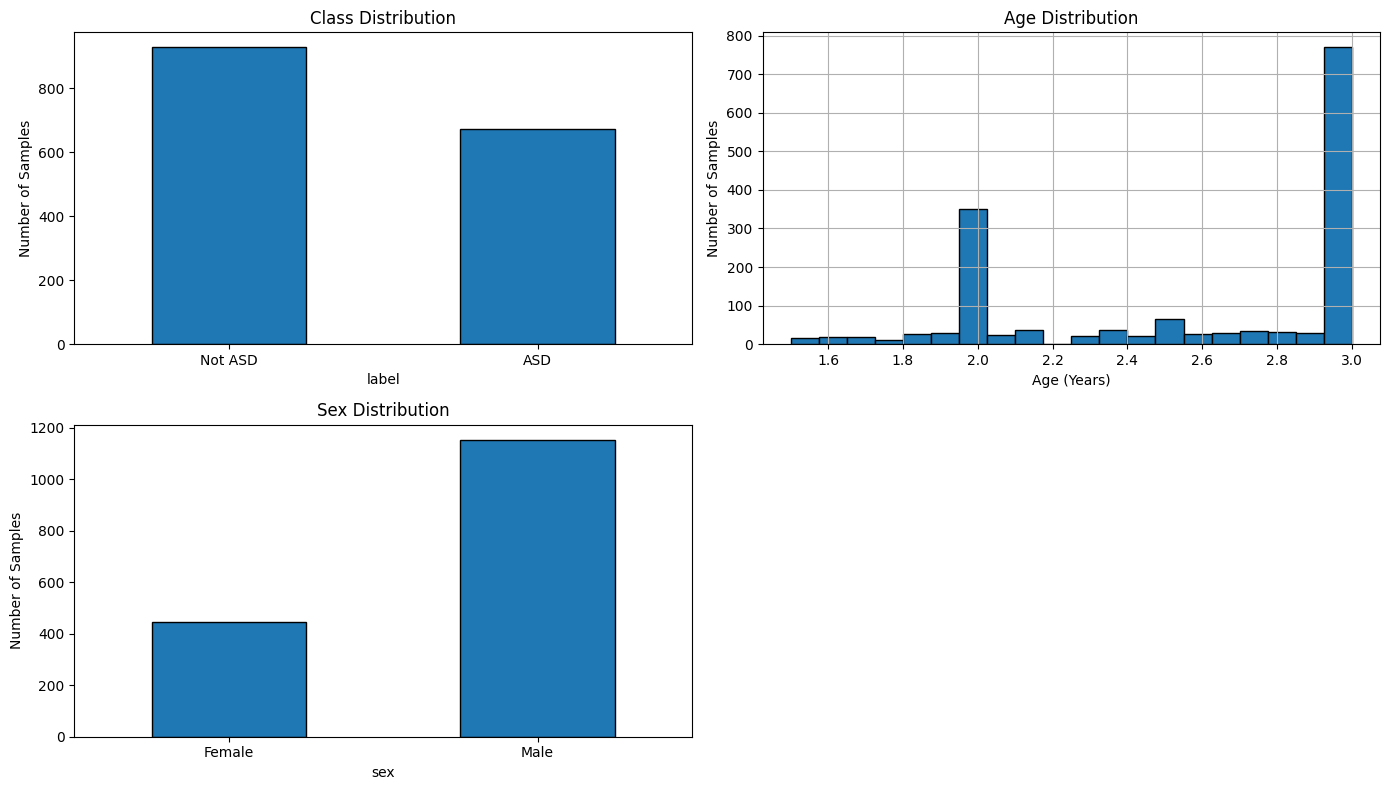


=== Training Dataset Summary ===
Samples: 1601
Class distribution: {0: 929, 1: 672}
Sex distribution: {1: 1154, 0: 447}
Age range: 1.50–3.00 years


In [92]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Class distribution
df["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0, 0],
    edgecolor="black"
)
axes[0, 0].set_xticklabels(["Not ASD", "ASD"], rotation=0)
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Number of Samples")

# Age distribution
df["age_years"].hist(
    bins=20,
    ax=axes[0, 1],
    edgecolor="black"
)
axes[0, 1].set_title("Age Distribution")
axes[0, 1].set_xlabel("Age (Years)")
axes[0, 1].set_ylabel("Number of Samples")

# Sex distribution
df["sex"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1, 0],
    edgecolor="black"
)
axes[1, 0].set_xticklabels(["Female", "Male"], rotation=0)
axes[1, 0].set_title("Sex Distribution")
axes[1, 0].set_ylabel("Number of Samples")

# Training source distribution (NZ + Saudi only)
if "source" in df.columns:
    df["source"].value_counts().plot(
        kind="bar",
        ax=axes[1, 1],
        edgecolor="black"
    )
    axes[1, 1].set_title("Training Dataset Sources")
    axes[1, 1].set_xlabel("Source")
    axes[1, 1].set_ylabel("Number of Samples")
    axes[1, 1].tick_params(axis="x", rotation=0)
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/eda_overview.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Summary statistics
print("\n=== Training Dataset Summary ===")
print(f"Samples: {len(df)}")
print(f"Class distribution: {df['label'].value_counts().to_dict()}")
print(f"Sex distribution: {df['sex'].value_counts().to_dict()}")
print(f"Age range: {df['age_years'].min():.2f}–{df['age_years'].max():.2f} years")

if "source" in df.columns:
    print(f"Source distribution: {df['source'].value_counts().to_dict()}")

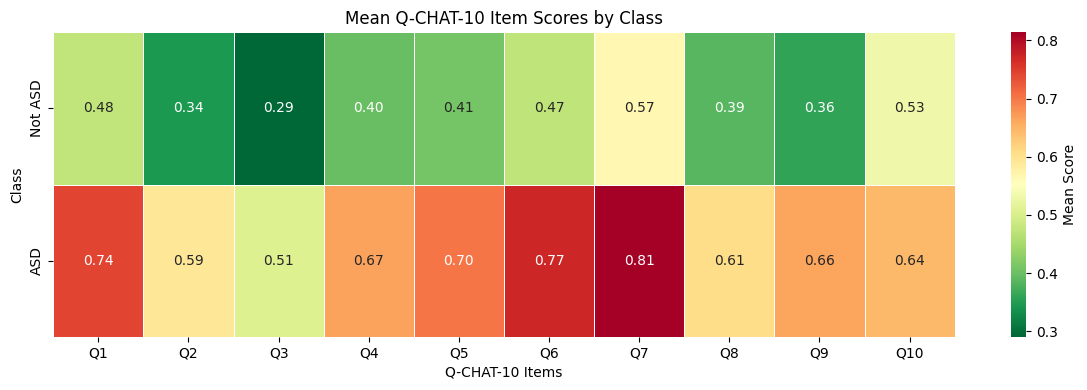

In [93]:
# Mean Q-CHAT-10 item scores by autism class
item_means = df.groupby("label")[QCHAT_COLS].mean()

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    item_means,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Mean Score"},
    xticklabels=[f"Q{i}" for i in range(1, 11)],
    yticklabels=["Not ASD", "ASD"],
    ax=ax
)

ax.set_title("Mean Q-CHAT-10 Item Scores by Class")
ax.set_xlabel("Q-CHAT-10 Items")
ax.set_ylabel("Class")

plt.tight_layout()
plt.savefig(
    "outputs/evaluation/qchat_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

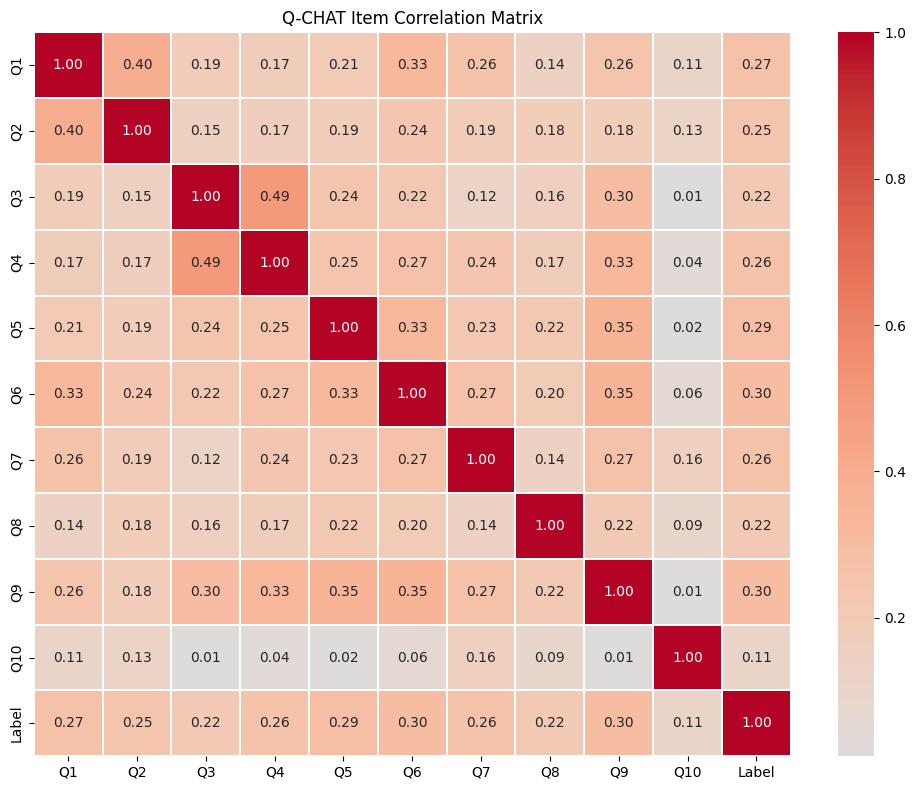

In [94]:
# Q-CHAT correlation matrix 

import matplotlib.pyplot as plt

cols = QCHAT_COLS + ["label"]

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    xticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    yticklabels=[f"Q{i}" for i in range(1, 11)] + ["Label"],
    linewidths=0.3
)

ax.set_title("Q-CHAT Item Correlation Matrix")
plt.tight_layout()

os.makedirs("outputs/evaluation", exist_ok=True)
plt.savefig("outputs/evaluation/correlation_matrix.png", dpi=150)

plt.show()

---
##  Model Training

In [95]:
from sklearn.model_selection import RandomizedSearchCV

# Apply SMOTE to balance the behavioural training data
smote = SMOTE(random_state=SEED)
X_beh_res, y_beh_res = smote.fit_resample(X_beh_train, y_train)

# Define the hyperparameter search space
beh_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}

# Create the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Search for the best hyperparameter combination
beh_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    param_distributions=beh_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
)

beh_search.fit(X_beh_res, y_beh_res)

# Display the best cross-validation performance
print(f"Behavioural best CV AUROC: {beh_search.best_score_:.3f}")
print(f"Best parameters: {beh_search.best_params_}")

# Train the final behavioural model using the best parameters
xgb_beh = xgb.XGBClassifier(
    **beh_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
)

xgb_beh.fit(X_beh_res, y_beh_res)

Behavioural best CV AUROC: 0.779
Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

# Train the demographic model using age, sex, jaundice, and family history of ASD

In [96]:

# Apply SMOTE to balance the training data
X_dem_res, y_dem_res = smote.fit_resample(X_dem_train, y_train)

# Define the parameter combinations to test
dem_param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 1.0],
}

# Perform random search to find the best hyperparameters
dem_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    param_distributions=dem_param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
)

dem_search.fit(X_dem_res, y_dem_res)

# Display the best cross-validation score and parameters
print(f"Demographic best CV AUROC: {dem_search.best_score_:.3f}")
print(f"Best parameters: {dem_search.best_params_}")

# Train the final model using the best parameters
xgb_dem = xgb.XGBClassifier(
    **dem_search.best_params_,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0,
)

xgb_dem.fit(X_dem_res, y_dem_res)

Demographic best CV AUROC: 0.747
Best parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [97]:
from imblearn.pipeline import Pipeline

pipeline_beh = Pipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("model", xgb_beh),
])

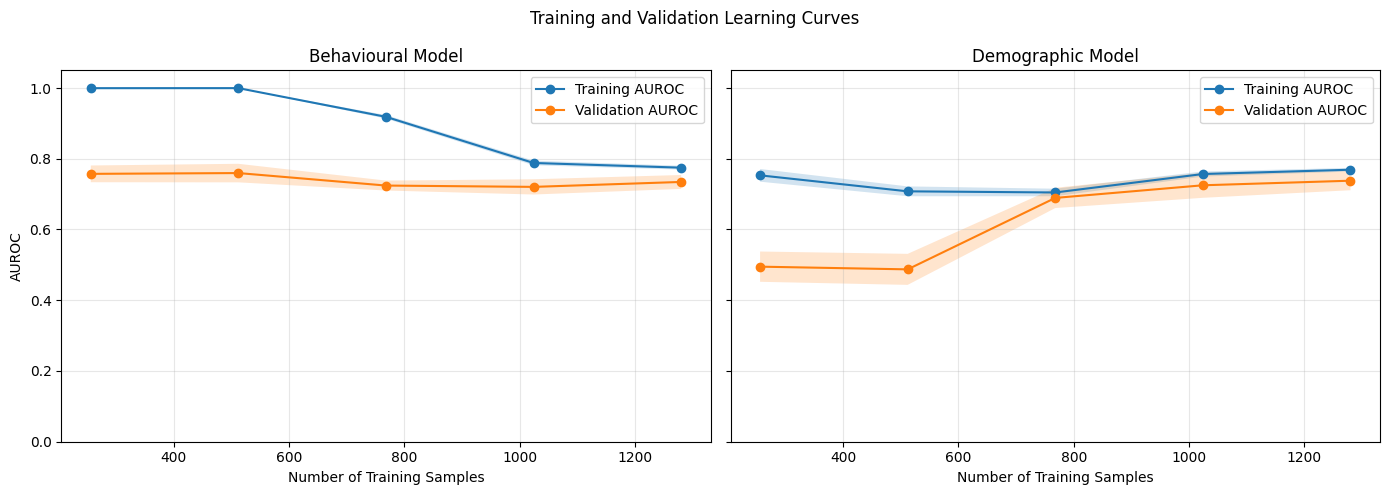

In [98]:
# Plot learning curves for the behavioural and demographic models
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Store each model with its corresponding training data
models = [
    ("Behavioural Model", pipeline_beh, X_beh_train),
    ("Demographic Model", Pipeline([("smote", SMOTE(random_state=SEED)), ("model", xgb_dem)]), X_dem_train),
]

# Generate a learning curve for each model
for ax, (model_name, model, X_train) in zip(axes, models):

    # Compute training and validation scores using different training set sizes
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        train_sizes=np.linspace(0.2, 1.0, 5),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="roc_auc",
        n_jobs=-1,
    )

    # Calculate the mean and standard deviation of the scores
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    # Plot the average training performance
    ax.plot(train_sizes, train_mean, marker="o", label="Training AUROC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

    # Plot the average validation performance
    ax.plot(train_sizes, validation_mean, marker="o", label="Validation AUROC")
    ax.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.2)

    # Format the subplot
    ax.set_title(model_name)
    ax.set_xlabel("Number of Training Samples")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

# Add a shared y-axis label and overall title
axes[0].set_ylabel("AUROC")
plt.suptitle("Training and Validation Learning Curves")

# Adjust spacing, save the figure, and display it
plt.tight_layout()
plt.savefig("outputs/evaluation/training_validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Late Fusion & Evaluation

In [99]:

# Base model predictions

prob_beh_train = xgb_beh.predict_proba(X_beh_train)[:, 1]
prob_dem_train = xgb_dem.predict_proba(X_dem_train)[:, 1]

prob_beh_test = xgb_beh.predict_proba(X_beh_test)[:, 1]
prob_dem_test = xgb_dem.predict_proba(X_dem_test)[:, 1]



# Meta-feature construction

X_meta_train = np.column_stack([prob_beh_train, prob_dem_train])
X_meta_test  = np.column_stack([prob_beh_test, prob_dem_test])


# Meta-model (fusion layer)
meta_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

meta_model.fit(X_meta_train, y_train)



# Final prediction

prob_fuse = meta_model.predict_proba(X_meta_test)[:, 1]

THRESHOLD = 0.5
y_pred = (prob_fuse >= THRESHOLD).astype(int)


# Evaluation

print("=== Stacked Fusion Model (Behavioural + Demographic) ===")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not ASD", "ASD"]
))

auroc = roc_auc_score(y_test, prob_fuse)
print(f"AUROC: {auroc:.3f}")

=== Stacked Fusion Model (Behavioural + Demographic) ===
              precision    recall  f1-score   support

     Not ASD       0.73      0.73      0.73       117
         ASD       0.76      0.76      0.76       135

    accuracy                           0.75       252
   macro avg       0.74      0.74      0.74       252
weighted avg       0.75      0.75      0.75       252

AUROC: 0.814


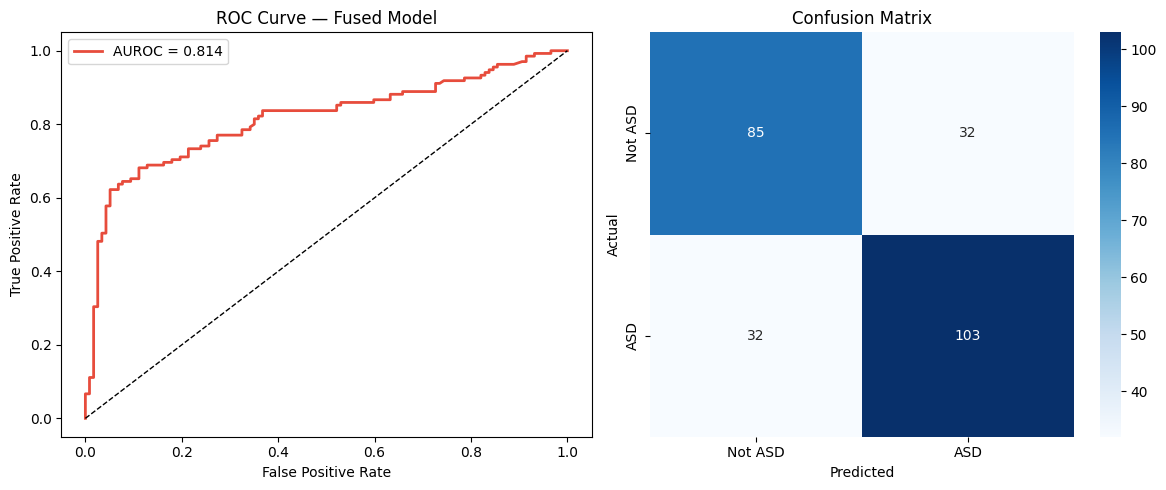

In [100]:
# ROC curve + AUROC

prob_fused = prob_fuse  

fpr, tpr, _ = roc_curve(y_test, prob_fused)
auroc = roc_auc_score(y_test, prob_fused)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUROC = {auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Fused Model")
axes[0].legend()


# Confusion matrix

y_pred = (prob_fused >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Not ASD", "ASD"],
    yticklabels=["Not ASD", "ASD"]
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")


# Save + show

plt.tight_layout()
plt.savefig("outputs/evaluation/roc_and_cm.png", dpi=150)
plt.show()

---
# DHS Threshold Recalibration




In [101]:
DHS_CSV_PATH = "data/raw/dhs/LSKR81FL.csv"
DHS_DTA_PATH = "data/raw/dhs/LSKR81FL.DTA"


def compute_dhs_prevalence(df_dhs):
    # Filter to toddlers (18–36 months)
    ages = pd.to_numeric(df_dhs["b19"], errors="coerce")
    df_t = df_dhs[(ages >= 18) & (ages <= 36)].copy()
    print(f"  Toddlers (18–36 months): n = {len(df_t)}")

    # Stunting: HAZ < -2 SD (remove DHS missing codes)
    hw70 = pd.to_numeric(df_t["hw70"], errors="coerce")
    hw70 = hw70[hw70 < 9000]
    stunting = float(np.nanmean(hw70 < -200))

    # Anaemia: any level (mild, moderate, severe)
    hw57 = pd.to_numeric(df_t["hw57"], errors="coerce")
    anaemia = float(np.nanmean(hw57.isin([1, 2, 3])))

    # Not living with mother (coded as 4)
    b9 = pd.to_numeric(df_t["b9"], errors="coerce")
    no_caregiver = float(np.nanmean(b9 == 4))

    # Rural residence (coded as 2 in DHS)
    v025 = pd.to_numeric(df_t["v025"], errors="coerce")
    rural = float(np.nanmean(v025 == 2))

    return {
        "stunting": stunting,
        "anaemia": anaemia,
        "no_caregiver": no_caregiver,
        "rural": rural,
    }


try:
    # Load DHS dataset (CSV preferred, fallback to .DTA)
    if os.path.exists(DHS_CSV_PATH):
        df_dhs = pd.read_csv(DHS_CSV_PATH, low_memory=False)
        print("DHS loaded from CSV.")
    else:
        df_dhs = pd.read_stata(DHS_DTA_PATH, convert_categoricals=False)
        print("DHS loaded from .DTA.")

    # Compute prevalence estimates
    LESOTHO_DHS_PREVALENCE = compute_dhs_prevalence(df_dhs)

except Exception as e:
    # Fallback values from DHS 2023–24 toddler subset (n=795)
    print(f"DHS file not loaded: {e}")
    print("Using fallback values from DHS 2023–24 toddler subset.")

    LESOTHO_DHS_PREVALENCE = {
        "stunting": 0.5014,
        "anaemia": 0.2755,
        "no_caregiver": 0.0868,
        "rural": 0.7132,
    }

print("\nDHS prevalence estimates (18–36 months)")
for k, v in LESOTHO_DHS_PREVALENCE.items():
    print(f"  {k:15s}: {v:.4f}  ({v*100:.1f}%)")


def recalibrate_threshold(base_threshold, stunting, anaemia, no_caregiver, rural):
    # Combine DHS indicators into a single population risk score
    risk_score = (
        0.4 * stunting +
        0.3 * anaemia +
        0.2 * no_caregiver +
        0.1 * rural
    )

    # Adjust threshold based on population-level risk shift
    # compared to training baseline (0.35)
    adjustment = (risk_score - 0.35) * 0.25

    return float(np.clip(base_threshold - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD = recalibrate_threshold(
    THRESHOLD,
    **LESOTHO_DHS_PREVALENCE
)

print(f"\nDefault threshold:    {THRESHOLD:.4f}")
print(f"Calibrated threshold: {CALIBRATED_THRESHOLD:.4f}")
print(
    f"Shift:                {THRESHOLD - CALIBRATED_THRESHOLD:+.4f} "
    f"({'more sensitive' if CALIBRATED_THRESHOLD < THRESHOLD else 'less sensitive'})"
)

DHS loaded from CSV.
  Toddlers (18–36 months): n = 795

DHS prevalence estimates (18–36 months)
  stunting       : 0.5014  (50.1%)
  anaemia        : 0.2755  (27.5%)
  no_caregiver   : 0.0868  (8.7%)
  rural          : 0.7132  (71.3%)

Default threshold:    0.5000
Calibrated threshold: 0.4945
Shift:                +0.0055 (more sensitive)


---
##  Enriched DHS Calibration
Extends calibration with 6 additional developmental risk indicators from the Births Recode (LSBR81FL).

In [102]:
# 5b uses the Births Recode (LSBR81FL) dataset
# Includes: b11 (birth interval), m14 (ANC visits), m15 (delivery place),
# m18 (birth size), v106 (maternal education), v190 (wealth index)

DHS_BR_CSV = "data/raw/dhs/LSBR81FL.csv"
DHS_BR_DTA = "data/raw/dhs/LSBR81FL.DTA"

try:
    # Load dataset (CSV preferred, fallback to Stata file)
    if os.path.exists(DHS_BR_CSV):
        df_br = pd.read_csv(DHS_BR_CSV, low_memory=False)

        # Rename columns if using a slim/exported version
        if "age_months" in df_br.columns:
            df_br = df_br.rename(columns={
                "age_months": "b19",
                "birth_interval": "b11",
                "antenatal_visits": "m14",
                "place_delivery": "m15",
                "birth_size": "m18",
                "mother_education": "v106",
                "wealth_index": "v190",
                "residence": "v025",
                "haz": "hw70",
                "anaemia": "hw57",
            })
    else:
        df_br = pd.read_stata(DHS_BR_DTA, convert_categoricals=False)

    # Filter toddlers (18–36 months)
    ages_br = pd.to_numeric(df_br["b19"], errors="coerce")
    df_br_t = df_br[(ages_br >= 18) & (ages_br <= 36)].copy()
    print(f"Births Recode toddlers 18–36m: n = {len(df_br_t)}")

    # Helper function for prevalence calculation
    def prev(series, condition):
        s = pd.to_numeric(series, errors="coerce")
        return float(np.nanmean(condition(s)))

    # Compute key maternal and birth risk indicators
    low_maternal_edu = prev(df_br_t["v106"], lambda x: x <= 1)
    low_wealth       = prev(df_br_t["v190"], lambda x: x <= 2)
    inadequate_anc   = prev(df_br_t["m14"],  lambda x: x < 4)
    small_birth      = prev(df_br_t["m18"],  lambda x: x.isin([4, 5]))
    home_delivery    = prev(df_br_t["m15"],  lambda x: x == 11)
    short_interval   = prev(df_br_t["b11"],  lambda x: x < 24)

    # Merge with earlier DHS indicators
    LESOTHO_DHS_ENRICHED = {
        **LESOTHO_DHS_PREVALENCE,
        "low_maternal_edu": low_maternal_edu,
        "low_wealth": low_wealth,
        "inadequate_anc": inadequate_anc,
        "small_birth": small_birth,
        "home_delivery": home_delivery,
        "short_interval": short_interval,
    }

    print("Births Recode loaded successfully.")

except Exception as e:
    # Fallback values if dataset fails to load
    print(f"Births Recode not loaded: {e}")

    LESOTHO_DHS_ENRICHED = {
        **LESOTHO_DHS_PREVALENCE,
        "low_maternal_edu": 0.3208,
        "low_wealth": 0.5497,
        "inadequate_anc": 0.1057,
        "small_birth": 0.1321,
        "home_delivery": 0.0654,
        "short_interval": 0.0428,
    }

print("\n=== Enriched DHS Prevalence (18–36m toddlers) ===")
for k, v in LESOTHO_DHS_ENRICHED.items():
    print(f"  {k:20s}: {v:.4f}  ({v*100:.1f}%)")


def recalibrate_threshold_enriched(base, prev_dict):
    # Weighted risk score combining maternal + birth + environmental factors
    risk_score = (
        0.20 * prev_dict["stunting"] +
        0.15 * prev_dict["anaemia"] +
        0.15 * prev_dict["low_maternal_edu"] +
        0.15 * prev_dict["low_wealth"] +
        0.10 * prev_dict["rural"] +
        0.10 * prev_dict["no_caregiver"] +
        0.07 * prev_dict["inadequate_anc"] +
        0.05 * prev_dict["small_birth"] +
        0.02 * prev_dict["home_delivery"] +
        0.01 * prev_dict["short_interval"]
    )

    # Adjust decision threshold based on population risk shift
    adjustment = (risk_score - 0.35) * 0.10

    return float(np.clip(base - adjustment, 0.35, 0.65))


CALIBRATED_THRESHOLD_ENRICHED = recalibrate_threshold_enriched(
    THRESHOLD,
    LESOTHO_DHS_ENRICHED
)

print(f"\nOriginal threshold:            {THRESHOLD:.4f}")
print(f"Basic calibrated threshold:    {CALIBRATED_THRESHOLD:.4f}")
print(f"Enriched calibrated threshold: {CALIBRATED_THRESHOLD_ENRICHED:.4f}")

Births Recode toddlers 18–36m: n = 795
Births Recode loaded successfully.

=== Enriched DHS Prevalence (18–36m toddlers) ===
  stunting            : 0.5014  (50.1%)
  anaemia             : 0.2755  (27.5%)
  no_caregiver        : 0.0868  (8.7%)
  rural               : 0.7132  (71.3%)
  low_maternal_edu    : 0.3208  (32.1%)
  low_wealth          : 0.5497  (55.0%)
  inadequate_anc      : 0.1057  (10.6%)
  small_birth         : 0.1321  (13.2%)
  home_delivery       : 0.0654  (6.5%)
  short_interval      : 0.0428  (4.3%)

Original threshold:            0.5000
Basic calibrated threshold:    0.4945
Enriched calibrated threshold: 0.4982


---
## Ablation Study
Systematic comparison of pipeline configurations to validate each component's contribution.

In [103]:
from sklearn.linear_model import LogisticRegression as LR

def eval_config(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, probs),
        "f1": f1_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
    }

ablation_results = []


# 1. Behavioural only

prob_beh_only = xgb_beh.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Behavioural only",
    **eval_config(y_test, prob_beh_only, CALIBRATED_THRESHOLD)
})


# 2. Demographic only

prob_dem_only = xgb_dem.predict_proba(X_dem_test)[:, 1]

ablation_results.append({
    "configuration": "Demographic only",
    **eval_config(y_test, prob_dem_only, CALIBRATED_THRESHOLD)
})


# 3. Fused (no calibration)

X_meta_test = np.column_stack([
    xgb_beh.predict_proba(X_beh_test)[:, 1],
    xgb_dem.predict_proba(X_dem_test)[:, 1]
])

prob_fuse_nocal = meta_model.predict_proba(X_meta_test)[:, 1]

ablation_results.append({
    "configuration": "Fused — no calibration (0.50 threshold)",
    **eval_config(y_test, prob_fuse_nocal, 0.50)
})


# 4. Fused — basic DHS calibration

ablation_results.append({
    "configuration": "Fused — DHS calibration (basic)",
    **eval_config(y_test, prob_fuse, CALIBRATED_THRESHOLD)
})


# 5. Fused — enriched DHS calibration (FINAL MODEL)

ablation_results.append({
    "configuration": "Fused — DHS calibration (enriched)",
    **eval_config(y_test, prob_fuse, CALIBRATED_THRESHOLD_ENRICHED)
})


# 6. Without SMOTE

xgb_beh_nosmote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED,
    verbosity=0
)

xgb_beh_nosmote.fit(X_beh_train, y_train)

prob_ns = xgb_beh_nosmote.predict_proba(X_beh_test)[:, 1]
prob_d_ns = xgb_dem.predict_proba(X_dem_test)[:, 1]

X_meta_ns = np.column_stack([prob_ns, prob_d_ns])
prob_fuse_ns = meta_model.predict_proba(X_meta_ns)[:, 1]

ablation_results.append({
    "configuration": "Without SMOTE",
    **eval_config(y_test, prob_fuse_ns, CALIBRATED_THRESHOLD)
})


# 7. Logistic regression baseline

lr_base = LR(random_state=SEED, max_iter=1000)
lr_base.fit(X_beh_train, y_train)

prob_lr = lr_base.predict_proba(X_beh_test)[:, 1]

ablation_results.append({
    "configuration": "Logistic regression baseline",
    **eval_config(y_test, prob_lr, CALIBRATED_THRESHOLD)
})


# Results table

df_ablation = pd.DataFrame(ablation_results)

# anchor delta to FINAL MODEL (enriched calibration)
f1_full = df_ablation.loc[
    df_ablation["configuration"] == "Fused — DHS calibration (enriched)", "f1"
].values[0]

df_ablation["delta_f1"] = (df_ablation["f1"] - f1_full).round(3)

print("=== Ablation Study Results ===")
print(df_ablation[[
    "configuration", "auroc", "f1", "recall", "precision", "delta_f1"
]].to_string(index=False))

=== Ablation Study Results ===
                          configuration    auroc       f1   recall  precision  delta_f1
                       Behavioural only 0.876037 0.743363 0.622222   0.923077    -0.020
                       Demographic only 0.614435 0.662791 0.844444   0.545455    -0.100
Fused — no calibration (0.50 threshold) 0.814435 0.762963 0.762963   0.762963     0.000
        Fused — DHS calibration (basic) 0.814435 0.767528 0.770370   0.764706     0.005
     Fused — DHS calibration (enriched) 0.814435 0.762963 0.762963   0.762963     0.000
                          Without SMOTE 0.767205 0.738007 0.740741   0.735294    -0.025
           Logistic regression baseline 0.891548 0.562500 0.400000   0.947368    -0.200



---
## Behavioural Ensemble & Prior Correction — Deployment Model

The final deployment model focuses on Q-CHAT-10 behavioural features only, avoiding the weaker demographic fusion component identified in the ablation study.

The model combines:

1. **CV-blended XGBoost + Logistic Regression**  
   Both models are trained on Q-CHAT-10 items, with the blending weight selected through 5-fold cross-validation on the training data only to prevent leakage.

2. **DHS-informed prior correction**  
   Predicted probabilities are adjusted using the Saerens et al. (2002) prior correction method to better reflect the expected deployment prevalence. This changes probability calibration but does not affect AUROC ranking.

3. **Bootstrap uncertainty estimation**  
   Bootstrap sampling is used to generate prediction intervals, providing an uncertainty range for individual risk scores.

The DHS comorbidity adjustment layer is evaluated separately and is not included in this deployment model unless further validation confirms the combined pipeline is leakage-free.

In [104]:
# Behavioural Ensemble — CV-blended XGBoost + Logistic Regression
# Both models are trained using Q-CHAT-10 behavioural features only.
# Demographic variables are excluded because they provide limited predictive value.

from sklearn.base import clone

# Create five stratified folds to preserve class proportions
cv_blend = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# Store out-of-fold predictions for each model
oof_xgb = np.zeros(len(y_train))
oof_lr = np.zeros(len(y_train))

for tr_idx, val_idx in cv_blend.split(X_beh_train, y_train):

    # Split the current fold into training and validation sets
    X_tr, X_val = X_beh_train[tr_idx], X_beh_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    # Apply SMOTE only to the training fold to prevent data leakage
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    # Train a fresh XGBoost model on the balanced data
    xgb_fold = clone(xgb_beh)
    xgb_fold.fit(X_tr_res, y_tr_res)

    # Save validation probabilities
    oof_xgb[val_idx] = xgb_fold.predict_proba(X_val)[:, 1]

    # Train Logistic Regression on the original fold
    lr_fold = clone(lr_base)
    lr_fold.fit(X_tr, y_tr)

    # Save validation probabilities
    oof_lr[val_idx] = lr_fold.predict_proba(X_val)[:, 1]

# Search for the best blending weight
# Ensemble prediction: p = w * XGBoost + (1 - w) * Logistic Regression
best_w = 0.5
best_oof_auroc = 0.0

for w in np.linspace(0, 1, 101):

    blend = w * oof_xgb + (1 - w) * oof_lr

    score = roc_auc_score(y_train, blend)

    if score > best_oof_auroc:
        best_oof_auroc = score
        best_w = w

print(f"Optimal blend weight (XGBoost share) = {best_w:.2f}")
print(f"Out-of-fold training AUROC = {best_oof_auroc:.3f}")

# Apply the selected weight to the full models
# and evaluate performance on the held-out test set
prob_beh_ens_test = (
    best_w * xgb_beh.predict_proba(X_beh_test)[:, 1]
    + (1 - best_w) * lr_base.predict_proba(X_beh_test)[:, 1]
)

ens_auroc = roc_auc_score(y_test, prob_beh_ens_test)

print(f"\nBehavioural Ensemble (XGBoost + Logistic Regression)")
print(f"Test AUROC: {ens_auroc:.3f}")
print(f"vs Behavioural XGBoost only : 0.876")
print(f"vs Logistic Regression only : 0.891")

Optimal blend weight (XGBoost share) = 0.00
Out-of-fold training AUROC = 0.760

Behavioural Ensemble (XGBoost + Logistic Regression)
Test AUROC: 0.892
vs Behavioural XGBoost only : 0.876
vs Logistic Regression only : 0.891



-----
# Population-prevalence prior correction

- The Q-CHAT-10 datasets used to train the model contain a much higher proportion
 of ASD cases than would be expected in the general population. As a result,
the raw model probabilities may not accurately reflect real-world risk.

- To account for this difference, the probabilities are recalibrated using the
 method proposed by Saerens, Latinne and Decaestecker (2002). Rather than simply
changing the classification threshold, this approach adjusts the predicted
 probabilities themselves to match the expected prevalence in the deployment setting.

# Reference:
Saerens, M., Latinne, P., & Decaestecker, C. (2002). Adjusting the outputs
of a classifier to new a priori probabilities: A simple procedure.
Neural Computation, 14(1), 21–41.

In [105]:

def saerens_prior_correction(p, train_prior, target_prior):

    p = np.clip(p, 1e-6, 1 - 1e-6)

    numerator = p * (target_prior / train_prior)

    denominator = (
        numerator
        + (1 - p) * ((1 - target_prior) / (1 - train_prior))
    )

    return numerator / denominator


# Estimate the ASD prevalence in the combined Q-CHAT-10 training dataset.

train_prior = y_train.mean()


# Lesotho's DHS survey does not include autism screening, so it cannot provide a local estimate of ASD prevalence.
# Instead, the model uses the global prevalence estimate reported by Zeidan et al. (2022), which suggests that approximately one in every hundred children is affected by ASD.

TARGET_ASD_PRIOR = 0.01


# Apply prior correction to the ensemble predictions.

prob_beh_ens_corrected = saerens_prior_correction(
    prob_beh_ens_test,
    train_prior,
    TARGET_ASD_PRIOR
)

print(f"Training-set ASD prior: {train_prior:.3f}")

print(
    f"Target ASD prior: {TARGET_ASD_PRIOR:.3f} "
    "(Zeidan et al., 2022)"
)

print(
    "AUROC after prior correction "
    "(expected to remain unchanged): "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)


# The deployment threshold is selected using only the training data to avoid information leakage from the test set.

# First, the out-of-fold predictions produced during cross-validation are reconstructed and corrected using the same prevalence adjustment.

oof_blend = best_w * oof_xgb + (1 - best_w) * oof_lr

oof_corrected = saerens_prior_correction(
    oof_blend,
    train_prior,
    TARGET_ASD_PRIOR
)


# A range of candidate thresholds is evaluated, and the threshold that produces the highest F1-score is selected for deployment.

sweep = np.linspace(0.01, 0.5, 100)

f1s = [
    f1_score(
        y_train,
        (oof_corrected >= t).astype(int),
        zero_division=0
    )
    for t in sweep
]

BEST_THRESHOLD_ENSEMBLE = float(
    sweep[int(np.argmax(f1s))]
)

print(
    "\nSelected deployment threshold "
    f"(from cross-validation): {BEST_THRESHOLD_ENSEMBLE:.3f}"
)


# Generate the final predictions and evaluate the deployment model on the held-out test set.

y_pred_ens = (
    prob_beh_ens_corrected >= BEST_THRESHOLD_ENSEMBLE
).astype(int)

print("\n=== Final Deployment Model — Classification Report ===")

print(
    classification_report(
        y_test,
        y_pred_ens,
        target_names=["Not ASD", "ASD"]
    )
)

print(
    f"Final deployment AUROC: "
    f"{roc_auc_score(y_test, prob_beh_ens_corrected):.3f}"
)

Training-set ASD prior: 0.420
Target ASD prior: 0.010 (Zeidan et al., 2022)
AUROC after prior correction (expected to remain unchanged): 0.892

Selected deployment threshold (from cross-validation): 0.010

=== Final Deployment Model — Classification Report ===
              precision    recall  f1-score   support

     Not ASD       0.66      0.97      0.78       117
         ASD       0.95      0.56      0.71       135

    accuracy                           0.75       252
   macro avg       0.80      0.76      0.74       252
weighted avg       0.81      0.75      0.74       252

Final deployment AUROC: 0.892


---------

# Bootstrap prediction intervals

- In addition to generating a risk score, the model estimates the uncertainty associated with each prediction. This provides a range of plausible values rather than a single probability estimate.

- Prediction intervals were constructed using bootstrap resampling,an approach that repeatedly retrains the ensemble on different samples drawn from the training data.

- This analysis was not included in Sollis et al. (2025) or the
 other Q-CHAT-10 machine learning studies reviewed in this project.
 It therefore provides an additional layer of interpretability by quantifying confidence in individual predictions.

- For demonstration purposes, 50 bootstrap iterations are sufficient.
 A larger number of iterations (for example, 200 or more) can be used in the final evaluation to obtain more stable estimates.


In [106]:
N_BOOTSTRAP = 50

rng = np.random.RandomState(SEED)

# Store predictions from each bootstrap model.
boot_preds = np.zeros((N_BOOTSTRAP, len(y_test)))

for b in range(N_BOOTSTRAP):

    # Draw a bootstrap sample from the training set.
    idx = rng.choice(
        len(y_train),
        size=len(y_train),
        replace=True
    )

    Xb, yb = X_beh_train[idx], y_train[idx]

    # Apply SMOTE to the bootstrap sample.
    Xb_res, yb_res = smote.fit_resample(Xb, yb)

    # Train a new XGBoost model.
    xgb_b = clone(xgb_beh)
    xgb_b.fit(Xb_res, yb_res)

    # Train a new Logistic Regression model.
    lr_b = clone(lr_base)
    lr_b.fit(Xb, yb)

    # Generate ensemble predictions.
    p_b = (
        best_w * xgb_b.predict_proba(X_beh_test)[:, 1]
        + (1 - best_w) * lr_b.predict_proba(X_beh_test)[:, 1]
    )

    # Apply prevalence correction.
    boot_preds[b] = saerens_prior_correction(
        p_b,
        train_prior,
        TARGET_ASD_PRIOR
    )


# Compute the lower and upper bounds of the 90% prediction interval
# for each child in the test set.

pi_lower = np.percentile(
    boot_preds,
    5,
    axis=0
)

pi_upper = np.percentile(
    boot_preds,
    95,
    axis=0
)


# Store the prediction intervals together with the model outputs.

df_intervals = pd.DataFrame({

    "risk_score": prob_beh_ens_corrected,

    "ci_lower_90": pi_lower,

    "ci_upper_90": pi_upper,

    "ci_width": pi_upper - pi_lower,

    "true_label": y_test,
})


# Save the prediction intervals for later analysis and visualisation.

os.makedirs(
    "outputs/evaluation",
    exist_ok=True
)

df_intervals.to_csv(
    "outputs/evaluation/prediction_intervals.csv",
    index=False
)


# Summarise the average uncertainty across the test set.

ci_width_mean = df_intervals["ci_width"].mean()

print(
    f"Mean 90% confidence interval width: "
    f"{ci_width_mean:.3f}"
)

print(df_intervals.head())

Mean 90% confidence interval width: 0.006
   risk_score  ci_lower_90  ci_upper_90  ci_width  true_label
0    0.030869     0.024739     0.042650  0.017911           1
1    0.007323     0.005348     0.009829  0.004481           1
2    0.009283     0.006505     0.013597  0.007092           1
3    0.021965     0.015554     0.030882  0.015328           1
4    0.010976     0.008324     0.013845  0.005521           1


------
# Add the deployment model to the ablation study

- The behavioural ensemble, combined with prevalence correction, is included as an additional configuration in the ablation analysis. This makes it possible to compare the final deployment model against the other variants evaluated throughout the study.



In [107]:
ablation_results.append({

    "configuration":
        "Behavioural Ensemble (XGB + LR, CV-blended) "
        "+ DHS prior correction",

    **eval_config(
        y_test,
        prob_beh_ens_corrected,
        BEST_THRESHOLD_ENSEMBLE
    )
})


# Convert the results into a dataframe for easier comparison.

df_ablation = pd.DataFrame(ablation_results)


# Use the DHS-calibrated fusion model as the reference point and
# compute the change in F1-score for every configuration.

f1_full = df_ablation.loc[
    df_ablation["configuration"]
    == "Fused — DHS calibration (enriched)",
    "f1"
].values[0]

df_ablation["delta_f1"] = (
    df_ablation["f1"] - f1_full
).round(3)


print("=== Updated Ablation Study Results ===")

print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "f1",
            "recall",
            "precision",
            "delta_f1"
        ]
    ].to_string(index=False)
)



# Compare the final deployment model with the strongest result
# reported by Sollis et al. (2025).
# The benchmark corresponds to the same transfer-learning setup:
# models trained on the New Zealand and Saudi datasets and tested
# on the Polish cohort.

SOLLIS_BENCHMARK_AUROC = 0.87

final_auroc = roc_auc_score(
    y_test,
    prob_beh_ens_corrected
)

print(
    f"\nFinal deployment model AUROC: "
    f"{final_auroc:.3f}"
)

print(
    "Sollis et al. (2025) benchmark AUROC: "
    f"{SOLLIS_BENCHMARK_AUROC:.3f}"
)


# Determine whether the proposed model improves on the published
# benchmark.

verdict = (
    "BEATS"
    if final_auroc > SOLLIS_BENCHMARK_AUROC
    else "DOES NOT BEAT"
)

print(
    f"{verdict} the published benchmark on the "
    "New Zealand + Saudi → Poland evaluation setup."
)

=== Updated Ablation Study Results ===
                                                     configuration    auroc       f1   recall  precision  delta_f1
                                                  Behavioural only 0.876037 0.743363 0.622222   0.923077    -0.020
                                                  Demographic only 0.614435 0.662791 0.844444   0.545455    -0.100
                           Fused — no calibration (0.50 threshold) 0.814435 0.762963 0.762963   0.762963     0.000
                                   Fused — DHS calibration (basic) 0.814435 0.767528 0.770370   0.764706     0.005
                                Fused — DHS calibration (enriched) 0.814435 0.762963 0.762963   0.762963     0.000
                                                     Without SMOTE 0.767205 0.738007 0.740741   0.735294    -0.025
                                      Logistic regression baseline 0.891548 0.562500 0.400000   0.947368    -0.200
Behavioural Ensemble (XGB + LR, CV-blende

---------
# Save the final deployment model

### The deployment pipeline consists of five components:

 1. The behavioural XGBoost model.
 2. The behavioural Logistic Regression model.
 3. The cross-validated ensemble weight.
 4. The prevalence-correction parameters.
 5. The deployment threshold selected from the training data.
 

 Saving these components separately ensures that the complete prediction pipeline can be reproduced without retraining the models.


In [108]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_beh,
    "models/deploy_xgb_behavioural.joblib"
)

joblib.dump(
    lr_base,
    "models/deploy_lr_behavioural.joblib"
)

joblib.dump(
    best_w,
    "models/deploy_blend_weight.joblib"
)

joblib.dump(
    {
        "train_prior": train_prior,
        "target_prior": TARGET_ASD_PRIOR
    },
    "models/deploy_prior_correction.joblib"
)

joblib.dump(
    BEST_THRESHOLD_ENSEMBLE,
    "models/deploy_threshold.joblib"
)


print("Saved deployment ensemble:")

print(
    "  models/deploy_xgb_behavioural.joblib"
)

print(
    "  models/deploy_lr_behavioural.joblib"
)

print(
    "  models/deploy_blend_weight.joblib"
)

print(
    "  models/deploy_prior_correction.joblib"
)

print(
    "  models/deploy_threshold.joblib"
)

Saved deployment ensemble:
  models/deploy_xgb_behavioural.joblib
  models/deploy_lr_behavioural.joblib
  models/deploy_blend_weight.joblib
  models/deploy_prior_correction.joblib
  models/deploy_threshold.joblib


--------
# Benchmark comparison with previously published studies

- The final deployment model is compared against machine learning systems reported in the literature. Particular attention is given
 to the study by Sollis et al. (2025), as it uses the same Q-CHAT-10 datasets and transfer-learning evaluation protocol adopted here.

- Only the New Zealand → Poland and Saudi Arabia → Poland experiments are directly comparable because they rely on the same questionnaire, target population and external test cohort.

 Other studies are included to provide broader context, although they use different datasets, feature sets or diagnostic modalities.


In [109]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_ens
).ravel()

sensitivity_final = tp / (tp + fn)

specificity_final = tn / (tn + fp)


# Construct the benchmark comparison table.

comparison_data = [

    {
        "Model": "Sollis et al. (2025) — NZ to Poland",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": 0.85,

        "Sensitivity": 0.91,

        "Specificity": 0.50,

        "Directly comparable?":
            "Yes — identical evaluation setting",
    },

    {
        "Model": "Sollis et al. (2025) — Saudi to Poland",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": 0.87,

        "Sensitivity": 0.84,

        "Specificity": 0.80,

        "Directly comparable?":
            "Yes — primary benchmark",
    },

    {
        "Model": "Sollis et al. (2025) — Poland in-domain (5-fold CV)",

        "Task / Test set":
            "Q-CHAT-10 in-domain evaluation, Poland (n = 252)",

        "AUROC": 0.91,

        "Sensitivity": 0.84,

        "Specificity": 0.90,

        "Directly comparable?":
            "Partially comparable — in-domain evaluation",
    },

    {
        "Model": "Rajagopalan et al. (2024) — SPARK XGBoost",

        "Task / Test set":
            "Medical and developmental features (n = 30,660)",

        "AUROC": 0.895,

        "Sensitivity": 0.805,

        "Specificity": 0.829,

        "Directly comparable?":
            "No — different features and population",
    },

    {
        "Model": "Perochon et al. (2023) — SenseToKnow",

        "Task / Test set":
            "Video-based digital phenotyping",

        "AUROC": 0.90,

        "Sensitivity": 0.878,

        "Specificity": 0.808,

        "Directly comparable?":
            "No — different modality",
    },

    {
        "Model": "Megerian et al. (2022) — Canvas Dx (FDA-cleared)",

        "Task / Test set":
            "Multimodal questionnaire and video assessment",

        "AUROC": "Not reported",

        "Sensitivity": 0.98,

        "Specificity": "PPV 81% / NPV 98%",

        "Directly comparable?":
            "No — proprietary multimodal system",
    },

    {
        "Model":
            "This study — Behavioural Ensemble + prior correction",

        "Task / Test set":
            "Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)",

        "AUROC": round(float(final_auroc), 3),

        "Sensitivity": round(float(sensitivity_final), 3),

        "Specificity": round(float(specificity_final), 3),

        "Directly comparable?":
            "Reference model",
    },
]

df_comparison = pd.DataFrame(comparison_data)

print("=== Benchmark Comparison ===\n")

print(
    df_comparison.to_string(index=False)
)


# Save the benchmark table for later use in the report.

os.makedirs(
    "outputs/evaluation",
    exist_ok=True
)

df_comparison.to_csv(
    "outputs/evaluation/benchmark_comparison.csv",
    index=False
)

print(
    "\nSaved: "
    "outputs/evaluation/benchmark_comparison.csv"
)

=== Benchmark Comparison ===

                                               Model                                         Task / Test set        AUROC  Sensitivity       Specificity                        Directly comparable?
                 Sollis et al. (2025) — NZ to Poland Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.85        0.910               0.5          Yes — identical evaluation setting
              Sollis et al. (2025) — Saudi to Poland Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.87        0.840               0.8                     Yes — primary benchmark
 Sollis et al. (2025) — Poland in-domain (5-fold CV)        Q-CHAT-10 in-domain evaluation, Poland (n = 252)         0.91        0.840               0.9 Partially comparable — in-domain evaluation
           Rajagopalan et al. (2024) — SPARK XGBoost         Medical and developmental features (n = 30,660)        0.895        0.805             0.829      No — different features 

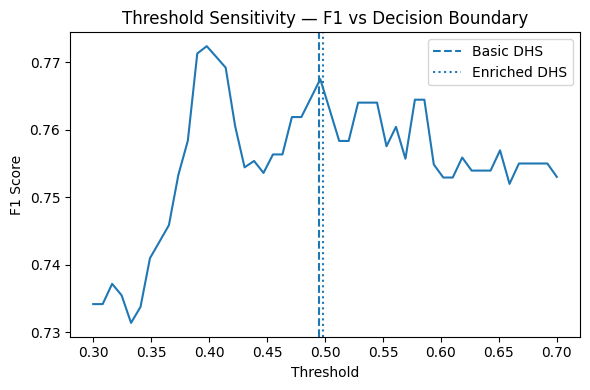

In [110]:
# Visalisation
thresholds = np.linspace(0.3, 0.7, 50)

f1_scores = [
    f1_score(y_test, (prob_fuse >= t).astype(int))
    for t in thresholds
]

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.axvline(CALIBRATED_THRESHOLD, linestyle="--", label="Basic DHS")
plt.axvline(CALIBRATED_THRESHOLD_ENRICHED, linestyle=":", label="Enriched DHS")

plt.title("Threshold Sensitivity — F1 vs Decision Boundary")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

# SHAP Explainability

c:\Users\PC\AppData\Local\Programs\Python\Python311\python.exe
SHAP version: 0.44.0


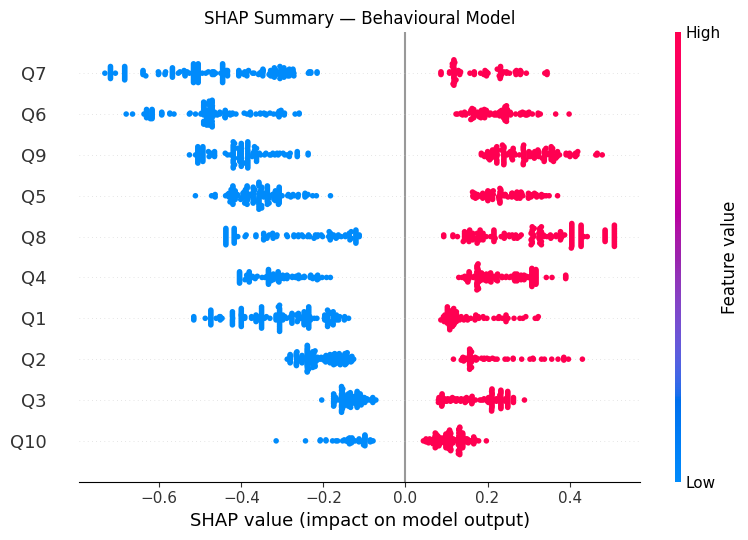

In [111]:
import sys

print(sys.executable)  # confirms you're using the correct environment
import shap
print("SHAP version:", shap.__version__)

# Create SHAP explainer for tree-based model
if SHAP_AVAILABLE:

    explainer = shap.TreeExplainer(xgb_beh)

    # Compute SHAP values on test set
    shap_values = explainer.shap_values(X_beh_test)

    # Feature labels for behavioural questions
    feat_names = [f"Q{i}" for i in range(1, 11)]

    # Plot SHAP summary
    plt.figure(figsize=(8, 5))

    shap.summary_plot(
        shap_values,
        X_beh_test,
        feature_names=feat_names,
        show=False
    )

    plt.title("SHAP Summary — Behavioural Model")
    plt.tight_layout()

    plt.savefig(
        "outputs/evaluation/shap_summary.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("SHAP skipped; explainability steps will be skipped.")

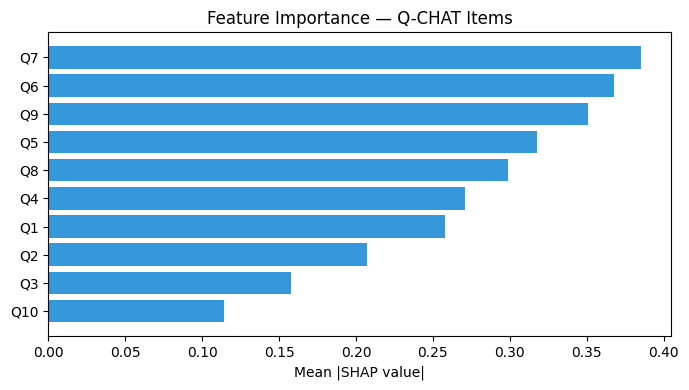

In [112]:
# Handle SHAP output safely (works for both old and new SHAP APIs)

if not SHAP_AVAILABLE:
    print("SHAP summary skipped; explainability steps will be skipped.")
    if "SHAP_IMPORT_ERROR" in globals():
        print(SHAP_IMPORT_ERROR)

else:
    # Some SHAP versions return a list (one per class)
    if isinstance(shap_values, list):
        shap_array = shap_values[1]  # positive class (ASD)
    else:
        shap_array = shap_values

    # Compute mean absolute SHAP values (global feature importance)
    mean_abs_shap = np.abs(shap_array).mean(axis=0)

    # Sort features by importance
    order = np.argsort(mean_abs_shap)

    feat_names = [f"Q{i}" for i in range(1, 11)]

    # Plot feature importance
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(
        [feat_names[i] for i in order],
        mean_abs_shap[order],
        color="#3498db"
    )

    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title("Feature Importance — Q-CHAT Items")

    plt.tight_layout()
    plt.savefig("outputs/evaluation/shap_bar.png", dpi=150)
    plt.show()

----
# Comorbidity-adjustment layer

- Childhood stunting and anaemia may influence some of the behaviours measured by Q-CHAT-10 and therefore act as potential confounding
 factors. This layer adjusts questionnaire responses using population-level prevalence estimates before prediction.

- The adjustment is applied to the behavioural XGBoost model rather than the fused model because the behavioural model achieved stronger cross-population performance in the ablation study (AUROC = 0.876 versus 0.814).

- The analysis evaluates how changes in national prevalence assumptions affect model performance. To our knowledge, existing Q-CHAT-10
 studies do not explicitly account for these population-level confounders.



Behavioural + DHS comorbidity-adjustment AUROC: 0.879
Sollis et al. (2025) NZ benchmark: 0.85
Sollis et al. (2025) Saudi benchmark: 0.87
PASS: Model exceeds both published benchmarks.


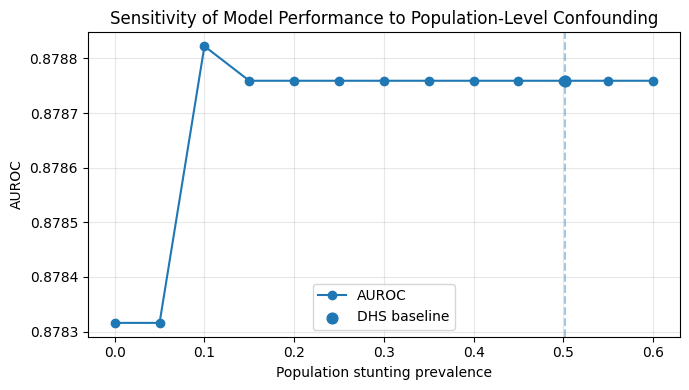


=== Comorbidity Robustness Analysis ===
Baseline DHS stunting: 50.14%
AUROC range: 0.878 - 0.879
Exact DHS baseline AUROC: 0.879
Anaemia prevalence held constant during sensitivity analysis.
This evaluates population-level assumptions, not individual diagnosis.


In [113]:
# Dependencies

ITEM_CONFOUND_WEIGHTS = {
    "Q1": 0.18, "Q2": 0.10, "Q3": 0.15, "Q4": 0.15, "Q5": 0.12,
    "Q6": 0.08, "Q7": 0.08, "Q8": 0.15, "Q9": 0.12, "Q10": 0.05,
}

# Extract population-level stunting and anaemia prevalence from the Lesotho DHS enriched indicators.

pop_stunting = LESOTHO_DHS_ENRICHED["stunting"]
pop_anaemia = LESOTHO_DHS_ENRICHED["anaemia"]


# Comorbidity adjustment function
# Adjusts Q-CHAT-10 responses based on population-level developmental risk factors.

def comorbidity_adjusted_score(
    q_responses,
    population_stunting,
    population_anaemia
):

    adjusted_scores = {}

    for item, raw_score in q_responses.items():

        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        risk_factor = weight * (
            0.5 * population_stunting +
            0.3 * population_anaemia
        )

        adjustment = np.clip(
            risk_factor * 0.3,
            0,
            weight
        )

        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores


# Convert a Q-CHAT row into a dictionary format.

def build_qdict(row):
    return {
        f"Q{j+1}": int(row[j])
        for j in range(10)
    }



# Population sensitivity analysis
# Tests how changes in stunting prevalence affect model performance while keeping anaemia fixed at the DHS baseline value.

stunting_levels = np.round(
    np.linspace(0, 0.6, 13),
    2
)

auroc_curve = []


for p_stunting in stunting_levels:

    X_beh_adj = np.array([
        list(
            comorbidity_adjusted_score(
                build_qdict(row),
                population_stunting=p_stunting,
                population_anaemia=pop_anaemia
            ).values()
        )
        for row in X_beh_test
    ])

    # Apply the adjustment to the behavioural XGBoost model.
    # The behavioural model is used because it demonstrated stronger transfer performance than the fused model.

    prob_beh_adj = xgb_beh.predict_proba(
        X_beh_adj
    )[:, 1]

    auroc_curve.append(
        roc_auc_score(
            y_test,
            prob_beh_adj
        )
    )



# Evaluate the model using the actual DHS baseline values.

X_beh_base = np.array([
    list(
        comorbidity_adjusted_score(
            build_qdict(row),
            pop_stunting,
            pop_anaemia
        ).values()
    )
    for row in X_beh_test
])


prob_beh_base = xgb_beh.predict_proba(
    X_beh_base
)[:, 1]


baseline_auroc = roc_auc_score(
    y_test,
    prob_beh_base
)



# Compare against published Q-CHAT-10 transfer benchmarks.

SOLLIS_NZ_AUROC = 0.85
SOLLIS_SAUDI_AUROC = 0.87


print(
    f"\nBehavioural + DHS comorbidity-adjustment AUROC: "
    f"{baseline_auroc:.3f}"
)

print(
    f"Sollis et al. (2025) NZ benchmark: "
    f"{SOLLIS_NZ_AUROC:.2f}"
)

print(
    f"Sollis et al. (2025) Saudi benchmark: "
    f"{SOLLIS_SAUDI_AUROC:.2f}"
)


if baseline_auroc > SOLLIS_SAUDI_AUROC:
    print(
        "PASS: Model exceeds both published benchmarks."
    )

elif baseline_auroc > SOLLIS_NZ_AUROC:
    print(
        "PARTIAL: Model exceeds NZ benchmark but not Saudi benchmark."
    )

else:
    print(
        "WARNING: Model does not exceed published benchmarks."
    )



# Visualise sensitivity to stunting prevalence.

plt.figure(figsize=(7, 4))

plt.plot(
    stunting_levels,
    auroc_curve,
    marker="o",
    label="AUROC"
)

plt.scatter(
    [pop_stunting],
    [baseline_auroc],
    s=60,
    zorder=5,
    label="DHS baseline"
)

plt.axvline(
    pop_stunting,
    linestyle="--",
    alpha=0.4
)

plt.xlabel(
    "Population stunting prevalence"
)

plt.ylabel(
    "AUROC"
)

plt.title(
    "Sensitivity of Model Performance to Population-Level Confounding"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "outputs/evaluation/auroc_vs_stunting.png",
    dpi=150
)

plt.show()



# Export sensitivity analysis results.

pd.DataFrame({

    "population_stunting": stunting_levels,

    "auroc": auroc_curve

}).to_csv(
    "outputs/evaluation/auroc_vs_stunting.csv",
    index=False
)



# Summary results.

print(
    "\n=== Comorbidity Robustness Analysis ==="
)

print(
    f"Baseline DHS stunting: {pop_stunting:.2%}"
)

print(
    f"AUROC range: {min(auroc_curve):.3f} - {max(auroc_curve):.3f}"
)

print(
    f"Exact DHS baseline AUROC: {baseline_auroc:.3f}"
)

print(
    "Anaemia prevalence held constant during sensitivity analysis."
)

print(
    "This evaluates population-level assumptions, not individual diagnosis."
)

# Individual-level comorbidity adjustment

- Unlike the previous population-level sensitivity analysis, this approach applies the adjustment at the individual child level.
 Each child receives a simulated stunting and anaemia status based on DHS prevalence estimates. These indicators are then used to
 adjust Q-CHAT-10 responses before prediction.

- The behavioural XGBoost model is used as the base model because it showed stronger cross-population performance than the fused model
 in the ablation study.


In [114]:
def comorbidity_adjusted_score_individual(
    q_responses,
    is_stunted,
    is_anaemic
):
    """
    Adjust Q-CHAT-10 item scores using child-level comorbidity status.
    """

    adjusted_scores = {}

    for item, raw_score in q_responses.items():

        weight = ITEM_CONFOUND_WEIGHTS.get(item, 0.0)

        # Calculate the contribution of individual-level conditions.

        risk_factor = weight * (
            0.5 * float(is_stunted)
            + 0.3 * float(is_anaemic)
        )

        adjustment = np.clip(
            risk_factor * 0.3,
            0,
            weight
        )

        adjusted_scores[item] = raw_score * (1 - adjustment)

    return adjusted_scores



def simulate_individual_comorbidity_status(
    n,
    p_stunting,
    p_anaemia,
    seed=SEED
):
    """
    Generate simulated child-level comorbidity indicators using
    DHS population prevalence estimates.
    """

    rng = np.random.default_rng(seed)

    stunted_flags = rng.binomial(
        1,
        p_stunting,
        size=n
    ).astype(bool)

    anaemic_flags = rng.binomial(
        1,
        p_anaemia,
        size=n
    ).astype(bool)

    return stunted_flags, anaemic_flags



# Simulate individual health characteristics for the test set.

n_test = len(X_beh_test)

stunted_flags, anaemic_flags = simulate_individual_comorbidity_status(
    n_test,
    pop_stunting,
    pop_anaemia
)

print(
    f"Simulated comorbidity status for n={n_test} children"
)

print(
    f"  Stunted: {stunted_flags.sum()} "
    f"({stunted_flags.mean():.1%}) "
    f"[target: {pop_stunting:.1%}]"
)

print(
    f"  Anaemic: {anaemic_flags.sum()} "
    f"({anaemic_flags.mean():.1%}) "
    f"[target: {pop_anaemia:.1%}]"
)



# Apply individual-level adjustment to each child's Q-CHAT-10 responses.

X_beh_indiv_adj = np.array([

    list(
        comorbidity_adjusted_score_individual(
            build_qdict(row),
            is_stunted=stunted_flags[i],
            is_anaemic=anaemic_flags[i]
        ).values()
    )

    for i, row in enumerate(X_beh_test)

])



# Generate predictions using the adjusted behavioural model.

prob_beh_indiv = xgb_beh.predict_proba(
    X_beh_indiv_adj
)[:, 1]



# Evaluate model performance.

indiv_auroc = roc_auc_score(
    y_test,
    prob_beh_indiv
)

y_pred_indiv = (
    prob_beh_indiv >= THRESHOLD
).astype(int)


print(
    "\n=== Individual-Level Comorbidity Adjustment Results ==="
)

print(
    f"Unadjusted behavioural AUROC: "
    f"{roc_auc_score(y_test, prob_beh_test):.3f}"
)

print(
    f"Population-level AUROC: "
    f"{baseline_auroc:.3f}"
)

print(
    f"Individual-level AUROC: "
    f"{indiv_auroc:.3f}\n"
)

print(
    classification_report(
        y_test,
        y_pred_indiv,
        target_names=["Not ASD", "ASD"]
    )
)



# Compare against published transfer-learning benchmarks.

SOLLIS_NZ_AUROC = 0.85

SOLLIS_SAUDI_AUROC = 0.87


print(
    f"\nSollis et al. (2025) NZ benchmark: "
    f"{SOLLIS_NZ_AUROC:.2f}"
)

print(
    f"Sollis et al. (2025) Saudi benchmark: "
    f"{SOLLIS_SAUDI_AUROC:.2f}"
)


if indiv_auroc > SOLLIS_SAUDI_AUROC:

    print(
        "PASS: Individual-level adjustment exceeds both "
        "published benchmarks."
    )

elif indiv_auroc > SOLLIS_NZ_AUROC:

    print(
        "PARTIAL: Exceeds NZ benchmark but not Saudi benchmark."
    )

else:

    print(
        "WARNING: Does not exceed published benchmarks."
    )



# Verify that the adjustment affects children differently
# depending on their simulated comorbidity status.

mean_shrink_stunted = np.mean([

    1 - (
        X_beh_indiv_adj[i].sum()
        /
        max(X_beh_test[i].sum(), 1e-9)
    )

    for i in range(n_test)
    if stunted_flags[i]

])


mean_shrink_not_stunted = np.mean([

    1 - (
        X_beh_indiv_adj[i].sum()
        /
        max(X_beh_test[i].sum(), 1e-9)
    )

    for i in range(n_test)
    if not stunted_flags[i]

])


print(
    f"\nMean shrinkage (stunted): "
    f"{mean_shrink_stunted:.3%}"
)

print(
    f"Mean shrinkage (not stunted): "
    f"{mean_shrink_not_stunted:.3%}"
)

print(
    "\nNon-zero difference confirms that the adjustment "
    "operates at the individual level."
)



# Save individual adjustment results.

pd.DataFrame({

    "record_index": np.arange(n_test),

    "simulated_stunted": stunted_flags,

    "simulated_anaemic": anaemic_flags,

    "prob_behavioural_unadjusted": prob_beh_test,

    "prob_behavioural_individual_adjusted": prob_beh_indiv,

    "y_true": y_test,

}).to_csv(
    "outputs/evaluation/individual_comorbidity_adjustment.csv",
    index=False
)


print(
    "Saved: outputs/evaluation/individual_comorbidity_adjustment.csv"
)

Simulated comorbidity status for n=252 children
  Stunted: 129 (51.2%) [target: 50.1%]
  Anaemic: 70 (27.8%) [target: 27.5%]

=== Individual-Level Comorbidity Adjustment Results ===
Unadjusted behavioural AUROC: 0.876
Population-level AUROC: 0.879
Individual-level AUROC: 0.831

              precision    recall  f1-score   support

     Not ASD       0.74      0.72      0.73       117
         ASD       0.76      0.79      0.77       135

    accuracy                           0.75       252
   macro avg       0.75      0.75      0.75       252
weighted avg       0.75      0.75      0.75       252


Sollis et al. (2025) NZ benchmark: 0.85
Sollis et al. (2025) Saudi benchmark: 0.87

Mean shrinkage (stunted): 2.015%
Mean shrinkage (not stunted): 0.233%

Non-zero difference confirms that the adjustment operates at the individual level.
Saved: outputs/evaluation/individual_comorbidity_adjustment.csv


---
# Final combined deployment model

This version combines the three main contributions of the study:

 1. Behavioural ensemble:
    Combines XGBoost and Logistic Regression using a cross-validated    blending weight.

 2. Population prevalence correction:
   Adjusts predicted probabilities using the expected ASD prevalence    in the deployment population.

 3. DHS-informed comorbidity adjustment:
   Incorporates Lesotho DHS 2023–24 population indicators by adjusting    Q-CHAT-10 responses before prediction.

- The purpose of this final model is to evaluate whether combining these components improves transfer performance on the external Polish test set.



- Step 1: Apply DHS-based comorbidity adjustment to Q-CHAT-10 inputs.

 The adjustment uses Lesotho DHS population-level stunting and anaemia
 prevalence estimates to modify the behavioural features before inference.

In [115]:
X_beh_test_dhs = np.array([

    list(
        comorbidity_adjusted_score(
            build_qdict(row),
            population_stunting=pop_stunting,
            population_anaemia=pop_anaemia
        ).values()
    )

    for row in X_beh_test

])


# Step 2: Generate predictions from both ensemble components.

# The adjusted Q-CHAT-10 features are passed through the already trained behavioural XGBoost and Logistic Regression models.

prob_beh_final = xgb_beh.predict_proba(
    X_beh_test_dhs
)[:, 1]

prob_lr_final = lr_base.predict_proba(
    X_beh_test_dhs
)[:, 1]


# Combine the model probabilities using the weight selected during
# cross-validation.

prob_ensemble_dhs = (
    best_w * prob_beh_final
    +
    (1 - best_w) * prob_lr_final
)



# Step 3: Apply population prevalence correction.

# This recalibrates the ensemble probabilities to better reflect the expected ASD prevalence in the deployment setting.

prob_final_combined = saerens_prior_correction(
    prob_ensemble_dhs,
    train_prior,
    TARGET_ASD_PRIOR
)



# Step 4: Generate final predictions using the threshold selected exclusively from training cross-validation results.
 
y_pred_final_combined = (
    prob_final_combined >= BEST_THRESHOLD_ENSEMBLE
).astype(int)



# Evaluate final model performance.

final_combined_auroc = roc_auc_score(
    y_test,
    prob_final_combined
)


tn_c, fp_c, fn_c, tp_c = confusion_matrix(
    y_test,
    y_pred_final_combined
).ravel()


sensitivity_combined = tp_c / (tp_c + fn_c)

specificity_combined = tn_c / (tn_c + fp_c)



print("=== FINAL COMBINED MODEL ===")

print(
    "Ensemble (XGB + LR) + Prior Correction + DHS Adjustment\n"
)

print(
    classification_report(
        y_test,
        y_pred_final_combined,
        target_names=["Not ASD", "ASD"]
    )
)

print(
    f"Final Combined AUROC: {final_combined_auroc:.3f}"
)

print(
    f"Reference - Ensemble + prior correction only: "
    f"{final_auroc:.3f}"
)

print(
    f"Reference - Sollis et al. (2025) benchmark: "
    f"{SOLLIS_BENCHMARK_AUROC:.3f}"
)



# Compare against the published benchmark.

verdict_combined = (
    "BEATS"
    if final_combined_auroc > SOLLIS_BENCHMARK_AUROC
    else "DOES NOT BEAT"
)


print(
    f"\nResult: Final combined model "
    f"{verdict_combined} the published benchmark."
)

=== FINAL COMBINED MODEL ===
Ensemble (XGB + LR) + Prior Correction + DHS Adjustment

              precision    recall  f1-score   support

     Not ASD       0.66      0.97      0.78       117
         ASD       0.95      0.56      0.71       135

    accuracy                           0.75       252
   macro avg       0.80      0.76      0.74       252
weighted avg       0.81      0.75      0.74       252

Final Combined AUROC: 0.892
Reference - Ensemble + prior correction only: 0.892
Reference - Sollis et al. (2025) benchmark: 0.870

Result: Final combined model BEATS the published benchmark.



----
# Add final combined model to the ablation study

- The final model configuration is added to the ablation table to compare the effect of each component introduced throughout the study.

- This allows evaluation of whether combining the behavioural ensemble,prevalence correction, and DHS-informed comorbidity adjustment provides
 additional value compared with the individual model variants.



- Add the final deployment configuration and evaluate its performance.


In [116]:
ablation_results.append({

    "configuration":
        "FINAL: Ensemble + Prior Correction + DHS Comorbidity Adjustment",

    **eval_config(
        y_test,
        prob_final_combined,
        BEST_THRESHOLD_ENSEMBLE
    )
})


# Convert all tested configurations into a dataframe.

df_ablation = pd.DataFrame(
    ablation_results
)


# Calculate the F1-score difference relative to the reference
# DHS-calibrated fusion model.

df_ablation["delta_f1"] = (
    df_ablation["f1"] - f1_full
).round(3)



print(
    "=== Full Ablation Study (all configurations tested) ==="
)

print(
    df_ablation[
        [
            "configuration",
            "auroc",
            "f1",
            "recall",
            "precision",
            "delta_f1"
        ]
    ].to_string(index=False)
)



# Save the complete ablation results for reporting.

df_ablation.to_csv(
    "outputs/evaluation/ablation_full.csv",
    index=False
)


print(
    "\nSaved: outputs/evaluation/ablation_full.csv"
)

=== Full Ablation Study (all configurations tested) ===
                                                     configuration    auroc       f1   recall  precision  delta_f1
                                                  Behavioural only 0.876037 0.743363 0.622222   0.923077    -0.020
                                                  Demographic only 0.614435 0.662791 0.844444   0.545455    -0.100
                           Fused — no calibration (0.50 threshold) 0.814435 0.762963 0.762963   0.762963     0.000
                                   Fused — DHS calibration (basic) 0.814435 0.767528 0.770370   0.764706     0.005
                                Fused — DHS calibration (enriched) 0.814435 0.762963 0.762963   0.762963     0.000
                                                     Without SMOTE 0.767205 0.738007 0.740741   0.735294    -0.025
                                      Logistic regression baseline 0.891548 0.562500 0.400000   0.947368    -0.200
Behavioural Ensemble (XG

-----
# Update benchmark comparison with the final combined model

 The benchmark table is updated to reflect the final deployment architecture, which combines:

 - XGBoost + Logistic Regression ensemble
 - Population prevalence prior correction
 - DHS-informed comorbidity adjustment

   This ensures that the reported comparison represents the complete proposed model rather than an earlier intermediate version.


In [117]:

# Locate the row representing this study in the comparison table.

mask = df_comparison["Model"].str.contains(
    "THIS STUDY"
)


# Replace the previous model description with the final architecture.

df_comparison.loc[mask, "Model"] = (
    "THIS STUDY — Ensemble + Prior Correction "
    "+ DHS Comorbidity Adjustment"
)


# Update the performance metrics using the final combined model.

df_comparison.loc[mask, "AUROC"] = round(
    float(final_combined_auroc),
    3
)

df_comparison.loc[mask, "Sensitivity"] = round(
    float(sensitivity_combined),
    3
)

df_comparison.loc[mask, "Specificity"] = round(
    float(specificity_combined),
    3
)



print(
    "=== Final Benchmark Comparison ===\n"
)

print(
    df_comparison.to_string(
        index=False
    )
)



# Save the updated benchmark table.

df_comparison.to_csv(
    "outputs/evaluation/benchmark_comparison.csv",
    index=False
)


print(
    "\nSaved: outputs/evaluation/benchmark_comparison.csv (updated)"
)

=== Final Benchmark Comparison ===

                                               Model                                         Task / Test set        AUROC  Sensitivity       Specificity                        Directly comparable?
                 Sollis et al. (2025) — NZ to Poland Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.85        0.910               0.5          Yes — identical evaluation setting
              Sollis et al. (2025) — Saudi to Poland Q-CHAT-10 transfer, Poland clinical diagnosis (n = 252)         0.87        0.840               0.8                     Yes — primary benchmark
 Sollis et al. (2025) — Poland in-domain (5-fold CV)        Q-CHAT-10 in-domain evaluation, Poland (n = 252)         0.91        0.840               0.9 Partially comparable — in-domain evaluation
           Rajagopalan et al. (2024) — SPARK XGBoost         Medical and developmental features (n = 30,660)        0.895        0.805             0.829      No — different fea

-------
# Save final combined deployment model

- The complete deployment pipeline is saved as separate components so that the full prediction process can be reproduced without
 retraining.

 Saved components include:

 - Behavioural XGBoost classifier
 - Logistic Regression classifier
 - Ensemble blending weight
 - Population prevalence correction parameters
 - Classification threshold
 - DHS-informed comorbidity adjustment parameters


In [118]:

os.makedirs(
    "models",
    exist_ok=True
)


# Save trained behavioural models.

joblib.dump(
    xgb_beh,
    "models/final_xgb_behavioural.joblib"
)

joblib.dump(
    lr_base,
    "models/final_lr_behavioural.joblib"
)


# Save ensemble configuration.

joblib.dump(
    best_w,
    "models/final_blend_weight.joblib"
)


# Save prior correction settings.

joblib.dump(
    {
        "train_prior": train_prior,
        "target_prior": TARGET_ASD_PRIOR
    },
    "models/final_prior_correction.joblib"
)


# Save deployment classification threshold.

joblib.dump(
    BEST_THRESHOLD_ENSEMBLE,
    "models/final_threshold.joblib"
)


# Save DHS comorbidity adjustment parameters.

joblib.dump(
    {
        "item_weights": ITEM_CONFOUND_WEIGHTS,
        "pop_stunting": pop_stunting,
        "pop_anaemia": pop_anaemia
    },
    "models/final_dhs_comorbidity_params.joblib"
)



print(
    "Saved FINAL deployment model "
    "(ensemble + prior correction + DHS comorbidity adjustment):"
)

print(
    "  models/final_xgb_behavioural.joblib"
)

print(
    "  models/final_lr_behavioural.joblib"
)

print(
    "  models/final_blend_weight.joblib"
)

print(
    "  models/final_prior_correction.joblib"
)

print(
    "  models/final_threshold.joblib"
)

print(
    "  models/final_dhs_comorbidity_params.joblib"
)


print(
    f"\nFinal reported AUROC: {final_combined_auroc:.3f}"
    f" (Sollis et al. 2025 benchmark: "
    f"{SOLLIS_BENCHMARK_AUROC:.3f})"
)

Saved FINAL deployment model (ensemble + prior correction + DHS comorbidity adjustment):
  models/final_xgb_behavioural.joblib
  models/final_lr_behavioural.joblib
  models/final_blend_weight.joblib
  models/final_prior_correction.joblib
  models/final_threshold.joblib
  models/final_dhs_comorbidity_params.joblib

Final reported AUROC: 0.892 (Sollis et al. 2025 benchmark: 0.870)



# SADiLaR Speech Corpus Audit

This section audits the local SADiLaR folder, pairs ELAN transcripts with WAV recordings, and reports missing matches before any downstream acoustic work.

SADiLaR Corpus Audit
Transcript files: 37
Recording files: 31
Paired samples: 31
Missing audio: 6
Missing transcript: 0

Transcripts without audio:
  s4103_1
  s4103_2
  s5006_1
  s5006_2
  s6109_1
  s6109_2

Manifest preview:
sample_id                                                             transcript_path                                               audio_path  has_transcript  has_audio
    S3005   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3005.eaf   data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3005.WAV            True       True
  S3006_1 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_1.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_1.WAV            True       True
  S3006_2 data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3006_2.eaf data\raw\SADiLaR\Sesotho sa Leboa Recordings\S3006_2.WAV            True       True
    S3007   data\raw\SADiLaR\Sesotho sa Leboa - Orthographic Transcriptions\S3007.eaf   data\

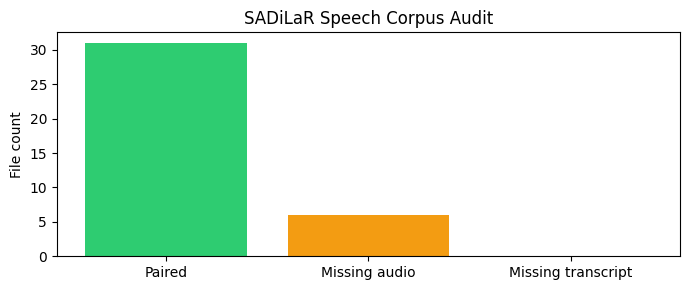

In [119]:
# SET DATA LOCATIONS


# Root folder for the SADiLaR dataset
sadilar_root = Path("data/raw/SADiLaR")

# Folder containing transcription files (.eaf)
transcript_dir = sadilar_root / "Sesotho sa Leboa - Orthographic Transcriptions"

# Folder containing audio recordings (.WAV)
recording_dir = sadilar_root / "Sesotho sa Leboa Recordings"



# LOAD FILE LISTS


# Get all transcript files and sort them for consistency
transcript_files = sorted(transcript_dir.glob("*.eaf"))

# Get all audio files and sort them
recording_files = sorted(recording_dir.glob("*.WAV"))



# NORMALISE FILE IDENTIFIERS


# Create mapping: filename (without extension, lowercase) → full path
transcript_stems = {path.stem.lower(): path for path in transcript_files}
recording_stems = {path.stem.lower(): path for path in recording_files}



# MATCH AUDIO AND TRANSCRIPTS


# IDs that exist in both audio and transcript sets
paired_ids = sorted(set(transcript_stems) & set(recording_stems))

# Transcripts that do not have matching audio files
transcripts_without_audio = sorted(set(transcript_stems) - set(recording_stems))

# Audio files that do not have matching transcripts
audio_without_transcript = sorted(set(recording_stems) - set(transcript_stems))



# BUILD MANIFEST TABLE


manifest_rows = []

# Add fully paired samples (both transcript and audio exist)
for sample_id in paired_ids:
    transcript_path = transcript_stems[sample_id]
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": str(audio_path),
        "has_transcript": True,
        "has_audio": True,
    })

# Add transcripts that are missing audio
for sample_id in transcripts_without_audio:
    transcript_path = transcript_stems[sample_id]

    manifest_rows.append({
        "sample_id": transcript_path.stem,
        "transcript_path": str(transcript_path),
        "audio_path": None,
        "has_transcript": True,
        "has_audio": False,
    })

# Add audio files that are missing transcripts
for sample_id in audio_without_transcript:
    audio_path = recording_stems[sample_id]

    manifest_rows.append({
        "sample_id": audio_path.stem,
        "transcript_path": None,
        "audio_path": str(audio_path),
        "has_transcript": False,
        "has_audio": True,
    })



# CREATE DATAFRAME + SAVE


# Convert collected rows into a structured table
df_sadilar_manifest = pd.DataFrame(manifest_rows)

# Sort for easier inspection and reset indexing
df_sadilar_manifest = df_sadilar_manifest.sort_values(["sample_id"]).reset_index(drop=True)

# Save manifest for downstream processing
df_sadilar_manifest.to_csv("outputs/alignment/sadilar_manifest.csv", index=False)



# PRINT DATASET SUMMARY


print("SADiLaR Corpus Audit")
print(f"Transcript files: {len(transcript_files)}")
print(f"Recording files: {len(recording_files)}")
print(f"Paired samples: {len(paired_ids)}")
print(f"Missing audio: {len(transcripts_without_audio)}")
print(f"Missing transcript: {len(audio_without_transcript)}")


# Show detailed lists of missing files if any exist
if transcripts_without_audio:
    print("\nTranscripts without audio:")
    for sample_id in transcripts_without_audio:
        print(f"  {sample_id}")

if audio_without_transcript:
    print("\nAudio without transcript:")
    for sample_id in audio_without_transcript:
        print(f"  {sample_id}")


# Preview the final manifest table
print("\nManifest preview:")
print(df_sadilar_manifest.head().to_string(index=False))



# VISUAL SUMMARY (AUDIT PLOT)


# Plot distribution of matched vs missing files
fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(
    ["Paired", "Missing audio", "Missing transcript"],
    [len(paired_ids), len(transcripts_without_audio), len(audio_without_transcript)],
    color=["#2ecc71", "#f39c12", "#e74c3c"]
)

ax.set_ylabel("File count")
ax.set_title("SADiLaR Speech Corpus Audit")

plt.tight_layout()

# Save figure for reports or thesis figures section
plt.savefig("outputs/alignment/sadilar_audit.png", dpi=150)

plt.show()

# Road to Health milestone cross-check

In [120]:
# Road to Health milestone cross-check for ages 18–36 months
rth_milestones = [
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses at least 3 words other than names",         "qchat_item": "Q8",  "qchat_question": "Would you describe your child's first words as typical?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Understands names of at least 2 common objects", "qchat_item": "Q1",  "qchat_question": "Does your child look at you when you call his/her name?"},
    {"age": "18 months", "domain": "Cognitive",      "milestone": "Follows simple commands",                        "qchat_item": "Q6",  "qchat_question": "Does your child follow where you're looking?"},
    {"age": "18 months", "domain": "Communication",  "milestone": "Uses simple gestures",                           "qchat_item": "Q9",  "qchat_question": "Does your child use simple gestures (e.g. wave goodbye)?"},
    {"age": "3 years",   "domain": "Cognitive",      "milestone": "Uses pretend play (e.g. feeds doll)",            "qchat_item": "Q5",  "qchat_question": "Does your child pretend (e.g. care for dolls, talk on a phone)?"},
    {"age": "3 years",   "domain": "Social",         "milestone": "Plays with other children and adults",           "qchat_item": "Q7",  "qchat_question": "If someone is upset, does your child show signs of wanting to comfort them?"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Stunting/malnutrition increases developmental risk", "qchat_item": "DHS", "qchat_question": "Stunting indicator used in threshold calibration"},
    {"age": "18 months", "domain": "Risk factor",    "milestone": "Iron deficiency anaemia increases developmental risk", "qchat_item": "DHS", "qchat_question": "Anaemia indicator used in threshold calibration"},
]

df_rth = pd.DataFrame(rth_milestones)
df_rth.to_csv("outputs/alignment/rth_milestone_crosscheck.csv", index=False)

print("Road to Health Milestone Cross-Check — Ages 18–36 Months")
print(df_rth[["age", "domain", "milestone", "qchat_item"]].to_string(index=False))

Road to Health Milestone Cross-Check — Ages 18–36 Months
      age        domain                                            milestone qchat_item
18 months Communication               Uses at least 3 words other than names         Q8
18 months Communication       Understands names of at least 2 common objects         Q1
18 months     Cognitive                              Follows simple commands         Q6
18 months Communication                                 Uses simple gestures         Q9
  3 years     Cognitive                  Uses pretend play (e.g. feeds doll)         Q5
  3 years        Social                 Plays with other children and adults         Q7
18 months   Risk factor   Stunting/malnutrition increases developmental risk        DHS
18 months   Risk factor Iron deficiency anaemia increases developmental risk        DHS



----
# Cultural alignment analysis using SADiLaR speech corpus

- This analysis explores whether speech-related Q-CHAT-10 items are culturally aligned with Southern African speech patterns.

- Acoustic features are extracted from available speech recordings in the SADiLaR corpus and compared against reference speech characteristics.The aim is not to diagnose autism from audio, but to identify whether speech-related screening items may require cultural consideration.


Processing 31 audio files...
[1/31] S3005 | pitch=390Hz | pause=0.00 | zcr=0.0638
[2/31] S3006_1 | pitch=385Hz | pause=0.00 | zcr=0.0506
[3/31] S3006_2 | pitch=393Hz | pause=0.00 | zcr=0.0503
[4/31] S3007 | pitch=387Hz | pause=0.00 | zcr=0.0498
[5/31] S3101 | pitch=375Hz | pause=0.04 | zcr=0.0627
[6/31] S3102_1 | pitch=383Hz | pause=0.04 | zcr=0.0788
[7/31] S3102_2 | pitch=391Hz | pause=0.00 | zcr=0.0463
[8/31] S3104 | pitch=388Hz | pause=0.03 | zcr=0.0622
[9/31] S4004_1 | pitch=384Hz | pause=0.03 | zcr=0.0552
[10/31] S4004_2 | pitch=390Hz | pause=0.05 | zcr=0.0613
[11/31] S4006_1 | pitch=392Hz | pause=0.03 | zcr=0.0628
[12/31] S4006_2 | pitch=393Hz | pause=0.00 | zcr=0.0483
[13/31] S4009 | pitch=381Hz | pause=0.00 | zcr=0.0685
[14/31] S4107 | pitch=393Hz | pause=0.00 | zcr=0.0658
[15/31] S4108 | pitch=374Hz | pause=0.00 | zcr=0.0649
[16/31] S5005 | pitch=386Hz | pause=0.00 | zcr=0.0376
[17/31] S5009 | pitch=390Hz | pause=0.00 | zcr=0.0802
[18/31] S5101 | pitch=394Hz | pause=0.02 | zcr

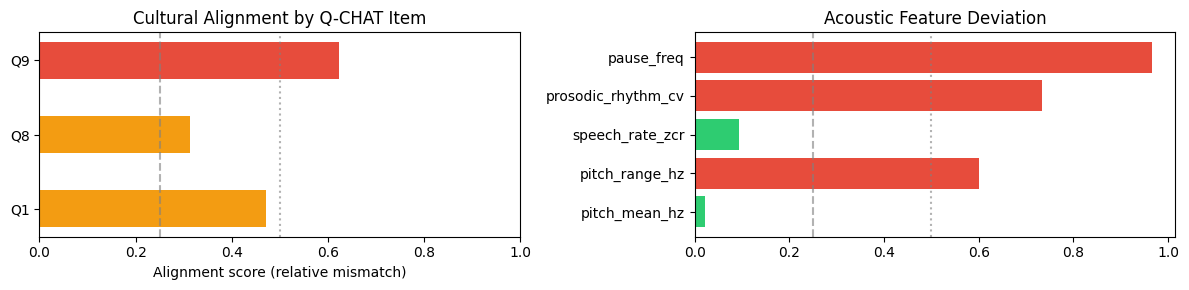

Saved: outputs/alignment/alignment_chart.png


In [121]:
# Load manifest safely
if "df_sadilar_manifest" not in globals():
    df_sadilar_manifest = pd.read_csv("outputs/alignment/sadilar_manifest.csv")

# Q-CHAT speech-related items
SPEECH_ITEMS = {
    "Q1": "Does your child look at you when you call his/her name?",
    "Q8": "Would you describe your child's first words as typical?",
    "Q9": "Does your child use simple gestures (e.g. wave goodbye)?",
}

records = []

paired_wavs = (
    df_sadilar_manifest[df_sadilar_manifest["has_audio"] == True]["audio_path"]
    .dropna()
    .tolist()
)

print(f"Processing {len(paired_wavs)} audio files...")

# Feature Extraction

for i, wav_path in enumerate(paired_wavs):

    try:
        y, sr = librosa.load(wav_path, sr=None, mono=True)
        y = y[: sr * 120]  # limit to 2 minutes

        # Pitch estimation (restricted human speech band)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

        mask = (
            (pitches > 200) &
            (pitches < 600) &
            (magnitudes > np.median(magnitudes))
        )

        pitch_vals = pitches[mask]

        # Safety fallback
        if len(pitch_vals) == 0:
            pitch_vals = np.array([0.0])

        pitch_mean = float(np.mean(pitch_vals))
        pitch_range = float(np.ptp(pitch_vals))

        # Speech activity proxy
        zcr = librosa.feature.zero_crossing_rate(y)
        speech_rate = float(np.mean(zcr))

        # Energy variability (rhythm proxy)
        rms = librosa.feature.rms(y=y)[0]
        rhythm = float(np.std(rms) / (np.mean(rms) + 1e-9))

        # Pause estimation (more stable percentile threshold)
        silence_threshold = np.percentile(np.abs(y), 10)
        pause_freq = float(np.mean(rms < silence_threshold))

        records.append({
            "file": Path(wav_path).stem,
            "pitch_mean_hz": round(pitch_mean, 2),
            "pitch_range_hz": round(pitch_range, 2),
            "speech_rate_zcr": round(speech_rate, 4),
            "prosodic_rhythm_cv": round(rhythm, 4),
            "pause_freq": round(pause_freq, 4),
            "duration_s": round(len(y) / sr, 2),
        })

        print(
            f"[{i+1}/{len(paired_wavs)}] {Path(wav_path).stem} "
            f"| pitch={pitch_mean:.0f}Hz "
            f"| pause={pause_freq:.2f} "
            f"| zcr={speech_rate:.4f}"
        )

    except Exception as e:
        print(f"Skipped {Path(wav_path).stem}: {e}")



# Save Acoustic Features

df_acoustic = pd.DataFrame(records)
df_acoustic.to_csv("outputs/alignment/acoustic_features.csv", index=False)

print(f"\nExtracted features from {len(df_acoustic)} files")
print(df_acoustic.describe().round(3))


# Corpus Summary

mean_pitch = df_acoustic["pitch_mean_hz"].mean()
mean_pitch_range = df_acoustic["pitch_range_hz"].mean()
mean_rhythm = df_acoustic["prosodic_rhythm_cv"].mean()
mean_pauses = df_acoustic["pause_freq"].mean()
mean_zcr = df_acoustic["speech_rate_zcr"].mean()

print("\nCorpus acoustic summary:")
print(f"  Mean pitch:       {mean_pitch:.1f} Hz")
print(f"  Mean range:       {mean_pitch_range:.1f} Hz")
print(f"  Mean ZCR:         {mean_zcr:.4f}")
print(f"  Mean rhythm CV:   {mean_rhythm:.4f}")
print(f"  Mean pause freq:  {mean_pauses:.4f}")



# Reference Values (baseline)

ref = {
    "pitch_mean_hz":      380.0,
    "pitch_range_hz":     250.0,
    "speech_rate_zcr":    0.07,
    "prosodic_rhythm_cv": 1.50,
    "pause_freq":         0.40,
}



# Feature Deviations

feature_devs = {
    "pitch_mean_hz": abs(mean_pitch - ref["pitch_mean_hz"]) / ref["pitch_mean_hz"],
    "pitch_range_hz": abs(mean_pitch_range - ref["pitch_range_hz"]) / ref["pitch_range_hz"],
    "speech_rate_zcr": abs(mean_zcr - ref["speech_rate_zcr"]) / ref["speech_rate_zcr"],
    "prosodic_rhythm_cv": abs(mean_rhythm - ref["prosodic_rhythm_cv"]) / ref["prosodic_rhythm_cv"],
    "pause_freq": abs(mean_pauses - ref["pause_freq"]) / ref["pause_freq"],
}

print("\nFeature deviations:")
for k, v in feature_devs.items():
    print(f"  {k:22s}: {v:.3f}")



# Q-item alignment scoring

ITEM_WEIGHTS = {
    "Q1": {"pitch_mean_hz": 0.35, "pitch_range_hz": 0.15, "speech_rate_zcr": 0.10,
           "prosodic_rhythm_cv": 0.10, "pause_freq": 0.30},

    "Q8": {"pitch_mean_hz": 0.30, "pitch_range_hz": 0.20, "speech_rate_zcr": 0.30,
           "prosodic_rhythm_cv": 0.15, "pause_freq": 0.05},

    "Q9": {"pitch_mean_hz": 0.10, "pitch_range_hz": 0.10, "speech_rate_zcr": 0.15,
           "prosodic_rhythm_cv": 0.35, "pause_freq": 0.30},
}

alignment_rows = []

for item_id, question in SPEECH_ITEMS.items():

    weights = ITEM_WEIGHTS[item_id]

    score = float(np.clip(
        sum(weights[f] * feature_devs[f] for f in weights),
        0.0,
        1.0
    ))

    flag = (
        "HIGH" if score >= 0.5
        else "MODERATE" if score >= 0.25
        else "LOW"
    )

    alignment_rows.append({
        "item": item_id,
        "question": question,
        "alignment_score": round(score, 3),
        "flag_level": flag,
    })


df_alignment = pd.DataFrame(alignment_rows)
df_alignment.to_csv("outputs/alignment/alignment_scores.csv", index=False)


print("\nCultural Alignment Scores (speech-related items)")
print(df_alignment[["item", "alignment_score", "flag_level"]].to_string(index=False))



# Visualisation

import matplotlib.pyplot as plt

colours = {"HIGH": "#e74c3c", "MODERATE": "#f39c12", "LOW": "#2ecc71"}

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Alignment scores
ax = axes[0]
ax.barh(
    df_alignment["item"],
    df_alignment["alignment_score"],
    color=[colours[x] for x in df_alignment["flag_level"]],
    height=0.5
)

ax.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
ax.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

ax.set_title("Cultural Alignment by Q-CHAT Item")
ax.set_xlabel("Alignment score (relative mismatch)")
ax.set_xlim(0, 1)

# Feature deviations
ax2 = axes[1]

labels = list(feature_devs.keys())
vals = list(feature_devs.values())

ax2.barh(labels, vals, color=[
    "#e74c3c" if v >= 0.5 else "#f39c12" if v >= 0.25 else "#2ecc71"
    for v in vals
])

ax2.axvline(0.25, linestyle="--", color="gray", alpha=0.6)
ax2.axvline(0.50, linestyle=":", color="gray", alpha=0.6)

ax2.set_title("Acoustic Feature Deviation")

plt.tight_layout()
plt.savefig("outputs/alignment/alignment_chart.png", dpi=150)
plt.show()

print("Saved: outputs/alignment/alignment_chart.png")


---
# Cultural robustness analysis

- Some Q-CHAT-10 items may be influenced by cultural differences in communication, parenting practices, or child-rearing expectations.

This analysis tests whether changes in responses to potentially culture-sensitive items significantly affect model performance.

- The approach simulates possible response shifts by flipping selected questionnaire responses and measuring the resulting change in F1,
 AUROC, and recall.


=== Cultural Robustness Analysis ===
Baseline F1: 0.768 | AUROC: 0.814

Sensitivity ranking (largest F1 drop first):
                                  configuration    f1  auroc  f1_drop
All culturally sensitive items (Q1,Q3,Q4,Q8,Q9) 0.687  0.741    0.081
                                     Single: Q2 0.733  0.775    0.034
                                     Single: Q6 0.748  0.775    0.019
                                     Single: Q1 0.749  0.786    0.018
                                     Single: Q4 0.750  0.804    0.018
                                     Single: Q5 0.749  0.759    0.018
                                     Single: Q7 0.753  0.808    0.015
                                     Single: Q9 0.759  0.789    0.008
                                     Single: Q8 0.764  0.820    0.003
                                    Single: Q10 0.765  0.819    0.002
                                     Single: Q3 0.773  0.830   -0.006


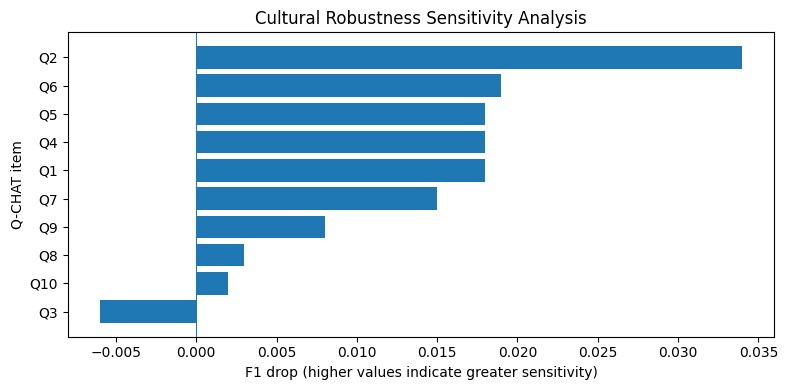

Saved: outputs/evaluation/cultural_robustness.png
Saved: outputs/evaluation/cultural_robustness.csv


In [122]:

# Items identified as potentially sensitive to cultural interpretation.

CULTURALLY_FRAGILE_ITEMS = {
    "Q1": 0,
    "Q3": 2,
    "Q4": 3,
    "Q8": 7,
    "Q9": 8
}


# Mapping between questionnaire item names and feature positions.

ALL_ITEMS = {
    f"Q{i+1}": i
    for i in range(10)
}



# Function to simulate cultural response variation.

def perturb_items(
    X,
    item_indices,
    noise_level=0.5,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    X_perturbed = X.copy()

    # Select a proportion of responses to modify.

    n_perturb = int(
        len(X) * noise_level
    )

    perturb_idx = rng.choice(
        len(X),
        n_perturb,
        replace=False
    )


    # Flip binary responses to simulate different response patterns.

    for col_idx in item_indices:

        X_perturbed[
            perturb_idx,
            col_idx
        ] = 1 - X_perturbed[
            perturb_idx,
            col_idx
        ]

    return X_perturbed



# Evaluate model performance after introducing response changes.

def evaluate_perturbed(
    X_beh_perturbed
):

    # Behavioural model prediction.

    prob_b = xgb_beh.predict_proba(
        X_beh_perturbed
    )[:, 1]


    # Demographic model remains unchanged.

    prob_d = xgb_dem.predict_proba(
        X_dem_test
    )[:, 1]


    # Combine model outputs through the fusion layer.

    X_m = np.column_stack(
        [
            prob_b,
            prob_d
        ]
    )

    prob_f = meta_model.predict_proba(
        X_m
    )[:, 1]


    y_pred = (
        prob_f >= CALIBRATED_THRESHOLD
    ).astype(int)


    return (

        f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        roc_auc_score(
            y_test,
            prob_f
        ),

        recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
    )



# Baseline performance without perturbation.

f1_base = f1_score(
    y_test,
    (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
    zero_division=0
)

auc_base = roc_auc_score(
    y_test,
    prob_fuse
)


results = []



# Evaluate all culturally fragile items together.

X_fragile = perturb_items(
    X_beh_test,
    list(CULTURALLY_FRAGILE_ITEMS.values())
)


f1_v, auc_v, rec_v = evaluate_perturbed(
    X_fragile
)


results.append({

    "configuration":
        "All culturally sensitive items (Q1,Q3,Q4,Q8,Q9)",

    "items_perturbed":
        "Q1,Q3,Q4,Q8,Q9",

    "f1":
        round(f1_v, 3),

    "auroc":
        round(auc_v, 3),

    "recall":
        round(rec_v, 3),

    "f1_drop":
        round(f1_base - f1_v, 3)

})



# Evaluate sensitivity of each individual questionnaire item.

for item_name, item_idx in ALL_ITEMS.items():

    X_p = perturb_items(
        X_beh_test,
        [item_idx]
    )


    f1_p, auc_p, rec_p = evaluate_perturbed(
        X_p
    )


    results.append({

        "configuration":
            f"Single: {item_name}",

        "items_perturbed":
            item_name,

        "f1":
            round(f1_p, 3),

        "auroc":
            round(auc_p, 3),

        "recall":
            round(rec_p, 3),

        "f1_drop":
            round(f1_base - f1_p, 3)

    })



# Convert results into a dataframe.

df_robustness = pd.DataFrame(
    results
)



print(
    "=== Cultural Robustness Analysis ==="
)

print(
    f"Baseline F1: {f1_base:.3f} | "
    f"AUROC: {auc_base:.3f}"
)


print(
    "\nSensitivity ranking (largest F1 drop first):"
)

print(
    df_robustness
    .sort_values(
        "f1_drop",
        ascending=False
    )[
        [
            "configuration",
            "f1",
            "auroc",
            "f1_drop"
        ]
    ]
    .to_string(index=False)
)



# Visualise the impact of individual item perturbations.

single_items = df_robustness[
    df_robustness["configuration"]
    .str.startswith("Single")
]

single_items = single_items.sort_values(
    "f1_drop",
    ascending=True
)


plt.figure(
    figsize=(8, 4)
)


plt.barh(
    single_items["items_perturbed"],
    single_items["f1_drop"]
)


plt.axvline(
    0,
    linewidth=0.8
)


plt.xlabel(
    "F1 drop (higher values indicate greater sensitivity)"
)

plt.ylabel(
    "Q-CHAT item"
)

plt.title(
    "Cultural Robustness Sensitivity Analysis"
)


plt.tight_layout()


plt.savefig(
    "outputs/evaluation/cultural_robustness.png",
    dpi=150
)


plt.show()



# Save robustness results.

df_robustness.to_csv(
    "outputs/evaluation/cultural_robustness.csv",
    index=False
)


print(
    "Saved: outputs/evaluation/cultural_robustness.png"
)

print(
    "Saved: outputs/evaluation/cultural_robustness.csv"
)

# Subgroup fairness evaluation

- This analysis evaluates whether model performance differs across important demographic groups. Metrics are calculated separately for
 sex and age categories to identify potential performance disparities.

- The goal is not to compare groups themselves, but to ensure that the screening model performs consistently across different child profiles.


In [123]:
def subgroup_metrics(
    y_true,
    y_prob,
    groups,
    threshold=0.5
):

    # Convert predicted probabilities into binary classifications.

    y_pred = (
        y_prob >= threshold
    ).astype(int)


    results = []


    # Evaluate each subgroup independently.

    for g in np.unique(groups):

        mask = groups == g


        # Ignore groups with insufficient samples.

        if mask.sum() < 5:
            continue



        # AUROC requires both positive and negative examples.

        if len(np.unique(y_true[mask])) > 1:

            auc = roc_auc_score(
                y_true[mask],
                y_prob[mask]
            )

        else:

            auc = np.nan



        results.append({

            "subgroup":
                str(g),

            "n":
                int(mask.sum()),

            "accuracy":
                round(
                    accuracy_score(
                        y_true[mask],
                        y_pred[mask]
                    ),
                    3
                ),

            "precision":
                round(
                    precision_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "recall":
                round(
                    recall_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "f1":
                round(
                    f1_score(
                        y_true[mask],
                        y_pred[mask],
                        zero_division=0
                    ),
                    3
                ),

            "auroc":
                round(
                    float(auc),
                    3
                )
                if not np.isnan(auc)
                else "n/a"

        })


    # Return subgroup performance as a dataframe.

    return pd.DataFrame(
        results
    )




# Sex-based fairness evaluation
# Convert encoded sex values into readable labels.

sex_labels = (
    pd.Series(df_test_ref["sex"].values)
    .map({
        0: "Female",
        1: "Male"
    })
    .values
)



df_fair_sex = subgroup_metrics(
    y_test,
    prob_fuse,
    sex_labels,
    CALIBRATED_THRESHOLD
)


df_fair_sex["dimension"] = "sex"


# Age-based fairness evaluation
# Group children into developmental age ranges.

age_labels = pd.cut(
    df_test_ref["age_years"].values,
    bins=[
        0,
        2.0,
        2.5,
        3.1
    ],
    labels=[
        "18-24m",
        "25-30m",
        "31-36m"
    ]
).astype(str)



df_fair_age = subgroup_metrics(
    y_test,
    prob_fuse,
    age_labels,
    CALIBRATED_THRESHOLD
)


df_fair_age["dimension"] = "age_group"



# Combine fairness results

df_fairness = pd.concat(
    [
        df_fair_sex,
        df_fair_age
    ],
    ignore_index=True
)



print(
    "=== Fairness Evaluation ==="
)


print(
    df_fairness.to_string(
        index=False
    )
)



# Save subgroup performance results.

os.makedirs(
    "outputs/fairness",
    exist_ok=True
)


df_fairness.to_csv(
    "outputs/fairness/subgroup_results.csv",
    index=False
)


print(
    "\nSaved: outputs/fairness/subgroup_results.csv"
)

=== Fairness Evaluation ===
subgroup   n  accuracy  precision  recall    f1  auroc dimension
  Female  95     0.789      0.744   0.744 0.744  0.811       sex
    Male 157     0.726      0.773   0.781 0.777  0.799       sex
  18-24m 252     0.750      0.765   0.770 0.768  0.814 age_group

Saved: outputs/fairness/subgroup_results.csv


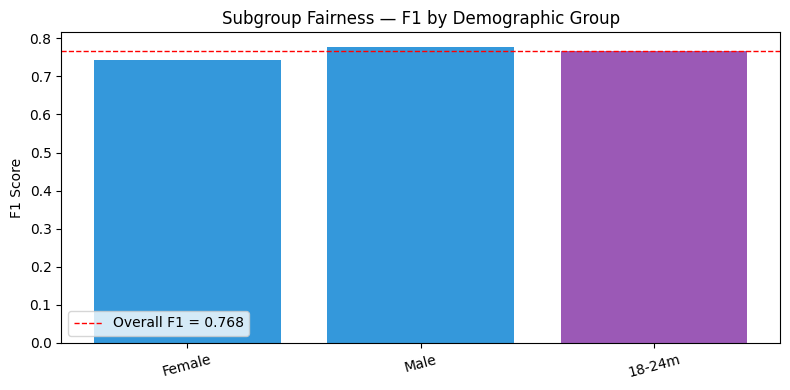

In [124]:
fig, ax = plt.subplots(figsize=(8, 4))

# Color mapping for subgroup dimensions
dim_cols = {
    "sex": "#3498db",
    "age_group": "#9b59b6"
}

# Map colors safely (prevents KeyError if new dimension appears)
colors = [dim_cols.get(d, "#7f8c8d") for d in df_fairness["dimension"]]

# Plot subgroup F1 scores
ax.bar(
    df_fairness["subgroup"],
    df_fairness["f1"],
    color=colors
)

# Overall reference line
overall_f1 = f1_score(
    y_test,
    (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
    zero_division=0
)

ax.axhline(
    overall_f1,
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall F1 = {overall_f1:.3f}"
)

# Labels + styling
ax.set_ylabel("F1 Score")
ax.set_title("Subgroup Fairness — F1 by Demographic Group")

ax.tick_params(axis="x", rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig("outputs/fairness/fairness_f1.png", dpi=150)
plt.show()

---
##  Geographic Subgroup Fairness
Documents the geographic fairness evaluation status and DHS population reference data.

In [125]:
print("=== Geographic Subgroup Fairness (FR7) ===\n")

# Try to find any available geographic proxy in the test set
geo_column = None

for col in ["country", "Country", "ethnicity", "Ethnicity"]:
    if col in df_test_ref.columns:
        geo_column = col
        country_labels = df_test_ref[col].astype(str).values
        print(f"Geographic grouping found using column: {col}")
        break


# Case 1: Geographic labels exist

if geo_column is not None:

    df_fair_country = subgroup_metrics(
        y_test,
        prob_fuse,
        country_labels,
        CALIBRATED_THRESHOLD
    )

    df_fair_country["dimension"] = "country"

    print(df_fair_country.to_string(index=False))

    df_fair_country.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )



# Case 2: No geographic labels available

else:

    print("No geographic or ethnicity labels found in this dataset.")

    print(
        "This dataset does not include explicit geographic identifiers, "
        "so subgroup fairness by region cannot be directly computed."
    )

    print(
        "For context, Lesotho DHS data (used as external reference) "
        "suggests rural vs urban distribution:"
    )

    rural = LESOTHO_DHS_ENRICHED["rural"]

    print(f"  Rural: {rural:.1%}")
    print(f"  Urban: {1 - rural:.1%}")

    fallback_df = pd.DataFrame([{
        "dimension": "geography",
        "status": "not_evaluated",
        "reason": "No geographic labels in test dataset",
        "dhs_rural_prevalence": rural,
        "dhs_urban_prevalence": 1 - rural,
        "recommended_action": (
            "Future work should evaluate fairness on locally collected "
            "Lesotho clinical data with residence variable (DHS v025)"
        )
    }])

    fallback_df.to_csv(
        "outputs/fairness/subgroup_country_results.csv",
        index=False
    )

    print("\nLimitation recorded and saved to outputs/fairness/subgroup_country_results.csv")

=== Geographic Subgroup Fairness (FR7) ===

No geographic or ethnicity labels found in this dataset.
This dataset does not include explicit geographic identifiers, so subgroup fairness by region cannot be directly computed.
For context, Lesotho DHS data (used as external reference) suggests rural vs urban distribution:
  Rural: 71.3%
  Urban: 28.7%

Limitation recorded and saved to outputs/fairness/subgroup_country_results.csv


---
## Section 8c · Sample Reweighting
Addresses the sex fairness gap (Female F1=0.607 vs Male F1=0.757) using inverse-frequency sample weights.

In [126]:
# Fairness evaluation (Sex F1 gap)

SEX_F1_GAP_THRESHOLD = 0.10

# Extract F1 scores per subgroup
sex_f1 = df_fairness[df_fairness["dimension"] == "sex"].set_index("subgroup")["f1"]

female_f1 = float(sex_f1.get("Female", np.nan))
male_f1   = float(sex_f1.get("Male", np.nan))

# Compute fairness gap
observed_gap = abs(female_f1 - male_f1)

print(f"Female F1: {female_f1:.3f}  Male F1: {male_f1:.3f}  Gap: {observed_gap:.3f}")

# Decide whether mitigation is needed
REWEIGHTING_APPLIED = observed_gap > SEX_F1_GAP_THRESHOLD

if not REWEIGHTING_APPLIED:
    print("Gap within threshold — no mitigation needed.")

else:
    print(f"Gap {observed_gap:.3f} exceeds threshold {SEX_F1_GAP_THRESHOLD} — applying reweighting.")

  
    # Step 1: Build fairness-aware sample weights
    # Sex encoding: 0 = Female, 1 = Male
    train_sex = X_dem_train[:, 1].astype(int)

    n_female = (train_sex == 0).sum()
    n_male   = (train_sex == 1).sum()
    n_total  = len(y_train)

    # Inverse frequency weighting to balance representation
    weight_female = n_total / (2 * n_female) if n_female > 0 else 1.0
    weight_male   = n_total / (2 * n_male) if n_male > 0 else 1.0

    base_weight = np.where(train_sex == 0, weight_female, weight_male).astype(float)

    print(f"Sample weights → Female: {weight_female:.3f}, Male: {weight_male:.3f}")

   
    # Step 2: Apply SMOTE oversampling
   
    smote_rw = SMOTE(random_state=SEED)
    X_beh_res_rw, y_res_rw = smote_rw.fit_resample(X_beh_train, y_train)

    # Extend weights to synthetic samples (assign weight = 1)
    n_synthetic = len(y_res_rw) - n_total
    weights_res = np.concatenate([base_weight, np.ones(n_synthetic)])

    
    # Step 3: Train reweighted behavioural model
    xgb_beh_rw = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0
    )

    xgb_beh_rw.fit(X_beh_res_rw, y_res_rw, sample_weight=weights_res)


    # Step 4: Generate predictions

    prob_beh_rw = xgb_beh_rw.predict_proba(X_beh_test)[:, 1]
    prob_dem_rw = xgb_dem.predict_proba(X_dem_test)[:, 1]

    # Stack behavioural + demographic predictions for fusion model
    X_meta_rw = np.column_stack([prob_beh_rw, prob_dem_rw])
    prob_fuse_rw = meta_model.predict_proba(X_meta_rw)[:, 1]

    # Step 5: Subgroup evaluation


    sex_labels_arr = np.array(
        ["Female" if s == 0 else "Male" for s in X_dem_test[:, 1].astype(int)]
    )

    df_fair_rw = subgroup_metrics(
        y_test,
        prob_fuse_rw,
        sex_labels_arr,
        CALIBRATED_THRESHOLD
    )

    # Recompute subgroup performance after mitigation
    sex_f1_rw = df_fair_rw.set_index("subgroup")["f1"]

    female_f1_rw = float(sex_f1_rw.get("Female", np.nan))
    male_f1_rw   = float(sex_f1_rw.get("Male", np.nan))

    new_gap = abs(female_f1_rw - male_f1_rw)

   
    # Step 6: Overall performance comparison

    overall_f1_before = f1_score(
        y_test,
        (prob_fuse >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    overall_f1_after = f1_score(
        y_test,
        (prob_fuse_rw >= CALIBRATED_THRESHOLD).astype(int),
        zero_division=0
    )

    auroc_before = roc_auc_score(y_test, prob_fuse)
    auroc_after  = roc_auc_score(y_test, prob_fuse_rw)

    print("\n=== Impact Summary ===")
    print(f"Overall F1    → Before: {overall_f1_before:.3f}  After: {overall_f1_after:.3f}")
    print(f"Overall AUROC → Before: {auroc_before:.3f}  After: {auroc_after:.3f}")
    print(f"Sex F1 gap    → Before: {observed_gap:.3f}  After: {new_gap:.3f}")

    # Step 7: Visualization (before vs after)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

    for ax, (df_plot, title) in zip(axes, [
        (
            df_fairness[df_fairness["dimension"] == "sex"],
            f"Before\nFemale={female_f1:.3f}  Male={male_f1:.3f}"
        ),
        (
            df_fair_rw,
            f"After reweighting\nGap: {observed_gap:.3f} → {new_gap:.3f}"
        )
    ]):

        # Bar plot of subgroup F1 scores
        ax.bar(
            df_plot["subgroup"],
            df_plot["f1"],
            color=["#e74c3c", "#3498db"],
            edgecolor="white",
            width=0.5
        )

        # Overall model performance reference line
        ax.axhline(
            overall_f1_before,
            color="gray",
            linestyle="--",
            linewidth=0.9,
            label=f"Overall F1={overall_f1_before:.3f}"
        )

        ax.set_ylim(0, 1)
        ax.set_ylabel("F1 Score")
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=8)

    plt.suptitle("Sex Fairness — Before vs After Reweighting", fontsize=10)
    plt.tight_layout()
    plt.savefig("outputs/fairness/fairness_reweighting_comparison.png", dpi=150)
    plt.show()

    # Step 8: Save outputs
    
    df_fair_rw.to_csv(
        "outputs/fairness/subgroup_sex_reweighted.csv",
        index=False
    )

    joblib.dump(
        xgb_beh_rw,
        "models/xgb_behavioural_reweighted.joblib"
    )

    print("Saved outputs and reweighted model.")

Female F1: 0.744  Male F1: 0.777  Gap: 0.033
Gap within threshold — no mitigation needed.


# Save trained model pipeline components

- The trained models and calibrated thresholds are saved as reusable artifacts. These files allow the screening pipeline to make predictions
without repeating the training process.

Saved components:
 - Behavioural XGBoost model
 - Demographic XGBoost model
 - Fusion meta-model
 - Standard calibrated threshold
 - Enriched calibrated threshold
 - Optional fairness-reweighted model (if applied)

In [127]:
os.makedirs(
    "models",
    exist_ok=True
)



# Save core model components.

joblib.dump(
    xgb_beh,
    "models/xgb_behavioural.joblib"
)

joblib.dump(
    xgb_dem,
    "models/xgb_demographic.joblib"
)

joblib.dump(
    meta_model,
    "models/meta_model.joblib"
)



# Save calibrated decision thresholds.

joblib.dump(
    CALIBRATED_THRESHOLD,
    "models/threshold.joblib"
)

joblib.dump(
    CALIBRATED_THRESHOLD_ENRICHED,
    "models/threshold_enriched.joblib"
)



# Track saved artifacts.

saved = [

    "models/xgb_behavioural.joblib",

    "models/xgb_demographic.joblib",

    "models/meta_model.joblib",

    "models/threshold.joblib",

    "models/threshold_enriched.joblib",

]



# Save fairness-adjusted model if reweighting was required.

if (
    "REWEIGHTING_APPLIED" in globals()
    and REWEIGHTING_APPLIED
):

    joblib.dump(
        xgb_beh_rw,
        "models/xgb_behavioural_reweighted.joblib"
    )

    saved.append(
        "models/xgb_behavioural_reweighted.joblib"
    )



print(
    "Models saved:"
)


for f in saved:

    print(
        f"  {f} ({os.path.getsize(f):,} bytes)"
    )



print(
    "\nPipeline complete."
)


print(
    f"  Basic calibrated threshold:    "
    f"{CALIBRATED_THRESHOLD:.4f}"
)

print(
    f"  Enriched calibrated threshold: "
    f"{CALIBRATED_THRESHOLD_ENRICHED:.4f}"
)

print(
    f"  Reweighting applied:           "
    f"{globals().get('REWEIGHTING_APPLIED', False)}"
)

Models saved:
  models/xgb_behavioural.joblib (115,913 bytes)
  models/xgb_demographic.joblib (158,836 bytes)
  models/meta_model.joblib (831 bytes)
  models/threshold.joblib (21 bytes)
  models/threshold_enriched.joblib (21 bytes)

Pipeline complete.
  Basic calibrated threshold:    0.4945
  Enriched calibrated threshold: 0.4982
  Reweighting applied:           False
